<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Building an MCP Server from Scratch</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

## What we're building, and why this way

By the end of this notebook we will have:

1. A **laptop-sized subset** of [OpenAlex](https://openalex.org) — the CC0 catalog of the global research system — pulled from its API and cached locally.
2. A **normalized SQLite database** (9 tables + full-text search) built from that subset.
3. A **detailed EDA** of the result, because we are about to hand this database to a language model and we need to know its blind spots before the model finds them.
4. A **modern MCP `2026-07-28` server written from scratch** — raw JSON-RPC over stdio, no SDK — exposing five tools and one resource over the database.
5. A **from-scratch client** that exercises the stateless server inside the notebook, so we see every byte on the wire.
6. The launch configuration that plugs the server into a current, 2026-capable MCP host.

**Why from scratch?** The official SDK is what you should usually use in production. But an SDK deliberately hides framing, per-request metadata, result envelopes, cache hints, and error classification — exactly the layers you need to understand when interoperability fails. Writing the dependency-free server once turns the SDK from magic into leverage.

**Why target only 2026?** MCP `2026-07-28` removed the legacy initialization handshake and protocol sessions. Mixing both eras in a first-principles implementation obscures the new model, so this server is modern-only and rejects legacy requests explicitly. If your deployment still needs `2025-11-25` clients, add a tested dual-era adapter rather than weakening the core example.

**Why OpenAlex?** Three reasons. It is CC0, so we can redistribute our derived subset with zero licensing hedging. It is a genuine entity graph — works, authors, institutions, sources, topics, citations — so multi-hop joins are inherent to the data, not bolted on. And "ask an agent about the literature" is a use case you can immediately rebuild against your own field.

### Setup

Note how much of the import list is standard library — `gzip`, `json`, `sqlite3`, `subprocess`, `sys`. That is deliberate: the MCP server we build must run as a bare subprocess wherever a host launches it, so everything on its critical path (storage, wire format, transport) uses only what ships with Python. The third-party imports serve the notebook, not the server: `requests` for the one-time API fetch, `numpy`/`pandas`/`matplotlib` for the EDA, and `watermark` to record the exact versions this was last run with — the reproducibility receipt for a notebook whose artifacts (the raw cache, the database) are meant to be rebuilt by other people on other machines.

In [1]:
import os
import gzip
import json
import sqlite3
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import requests

import matplotlib
import matplotlib.pyplot as plt

import watermark

%load_ext watermark
%matplotlib inline

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 50d7324173ffecf8d1de4b3a011e57b23d13c926

json      : 2.0.9
matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.3
requests  : 2.34.2
watermark : 2.6.0



In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Configuration

Everything tunable lives here, for three reasons: readers should be able to point this at **their own field** by editing one cell; the fetch step is expensive, so its knobs must be explicit; and the file paths are shared by the notebook *and* the MCP server we write later, so they are defined exactly once.

Notes on the knobs:

* `SEARCH_QUERY` uses OpenAlex full-text search over titles and abstracts. Quotes make it a phrase. Avoid commas — in the OpenAlex API, commas separate filter clauses.
* `MAX_RECORDS` is the laptop-feasibility valve. 25k works → a database in the low hundreds of MB, and every query in this notebook runs in seconds.
* `OPENALEX_API_KEY` is required for a fresh fetch. OpenAlex retired its old `mailto`-based polite pool in February 2026; register a free key and export it in your environment. The checked-in raw cache lets the rest of the notebook run without credentials.

In [4]:
SEARCH_QUERY = '"scaling laws"'        # phrase search; edit to taste
FROM_DATE    = "2015-01-01"
MAX_RECORDS  = 25_000                  # hard cap = laptop feasibility
API_KEY      = os.environ.get("OPENALEX_API_KEY")

DATA_DIR = Path("data")
RAW_PATH = DATA_DIR / "openalex_raw.jsonl.gz"
DB_PATH  = DATA_DIR / "openalex.db"
DATA_DIR.mkdir(exist_ok=True)

## 1. Getting the data: API slice, not snapshot

OpenAlex offers two access paths, and picking the right one *is* the subsetting decision:

* The **full snapshot** is the whole catalog — hundreds of GB compressed. Wonderful for bibliometrics at scale; hostile to a tutorial.
* The **API** accepts filters server-side, so we download only the slice we asked for. A topical phrase plus a date floor gives us a coherent corpus small enough to commit to a repo.

Four implementation choices that matter:

**Authenticate explicitly.** OpenAlex replaced the old email-based polite pool with API keys in February 2026. A fresh fetch now requires `OPENALEX_API_KEY`; cached artifacts remain usable without it.

**Cursor pagination, not page numbers.** OpenAlex caps basic paging at 10k results; `cursor=*` paging has no such limit. Each response hands us `meta.next_cursor` for the next request. The supported page size is now 100 — the older 200-row behavior is deprecated.

**`select=` field trimming.** A full work record carries far more than we need. Asking only for our fields cuts payload size roughly an order of magnitude — this is the difference between a 5-minute fetch and an hour.

**Cache the raw JSON, separately from the database.** The fetch is the only step here that costs real time and hits someone else's servers. By writing raw JSON Lines to disk first, every downstream decision (schema, cleaning, indexing) becomes re-runnable in seconds without re-fetching. Separation of *acquisition* from *modeling* is the single habit that makes pipelines like this pleasant to iterate on.

In [5]:
SELECT_FIELDS = ",".join([
    "id", "doi", "title", "publication_year", "publication_date", "type",
    "cited_by_count", "primary_location", "authorships", "topics",
    "primary_topic", "referenced_works", "abstract_inverted_index",
])


def fetch_openalex(query, from_date, max_records, out_path):
    """Cursor-page through /works and stream raw records to gzip JSONL."""
    if not API_KEY:
        raise RuntimeError(
            "Set OPENALEX_API_KEY before deleting the raw-data cache")

    url = "https://api.openalex.org/works"
    params = {
        "filter": (f"title_and_abstract.search:{query},"
                   f"from_publication_date:{from_date},type:article"),
        "select": SELECT_FIELDS,
        "per_page": 100,
        "cursor": "*",
        "api_key": API_KEY,
    }

    n, page = 0, 0
    with gzip.open(out_path, "wt") as fh:
        while params["cursor"] and n < max_records:
            resp = requests.get(url, params=params, timeout=60)
            if resp.status_code == 429:            # rate limited: back off
                wait = int(resp.headers.get("Retry-After", 5))
                print(f"429 - sleeping {wait}s")
                time.sleep(wait)
                continue
            resp.raise_for_status()
            data = resp.json()
            for rec in data["results"]:
                fh.write(json.dumps(rec) + "\n")
                n += 1
                if n >= max_records:
                    break
            params["cursor"] = data["meta"].get("next_cursor")
            page += 1
            if page % 10 == 0:
                print(f"  page {page}: {n:,} works "
                      f"(of {data['meta']['count']:,} matching)")
            time.sleep(0.15)                        # be a good citizen
    print(f"done: {n:,} works -> {out_path}")


if RAW_PATH.exists():
    print(f"cache hit: {RAW_PATH} - delete it to re-fetch")
else:
    fetch_openalex(SEARCH_QUERY, FROM_DATE, MAX_RECORDS, RAW_PATH)

cache hit: data/openalex_raw.jsonl.gz - delete it to re-fetch


Sanity-check the cache before investing in a schema: how many records, and what does one look like? Thirty seconds here saves an hour of debugging a loader built on wrong assumptions.

In [6]:
with gzip.open(RAW_PATH, "rt") as fh:
    first = json.loads(fh.readline())
    n_records = 1 + sum(1 for _ in fh)

print(f"{n_records:,} records cached")
print("top-level keys:", sorted(first.keys()))
print("\ntitle:", first.get("title"))
print("authorships:", len(first.get("authorships") or []),
      "| refs:", len(first.get("referenced_works") or []))

11,791 records cached
top-level keys: ['abstract_inverted_index', 'authorships', 'cited_by_count', 'doi', 'id', 'primary_location', 'primary_topic', 'publication_date', 'publication_year', 'referenced_works', 'title', 'topics', 'type']

title: Scaling laws predict global microbial diversity
authorships: 2 | refs: 59


## 2. From JSON documents to a relational model

Each OpenAlex record is a deeply nested document. We could dump them into one flat DataFrame — and for a pure analysis notebook we might. We deliberately don't, for one reason with two faces:

**The joins are the point.** The premise of the whole tutorial is that agent questions like *"which institutions dominate this literature, and who are their key authors?"* require composing information across entities. If we pre-join everything into a flat table, we've done the model's reasoning for it — and simultaneously frozen which questions can be asked. Normalized entities + link tables keep the question space open, and force the agent to demonstrate exactly the multi-step tool use we want to study.

The schema mirrors OpenAlex's own entity graph:

```
   sources ◄────── works ──────► topics      (via work_topics)
                  ▲  │  ▲
                  │  │  └──────── works      (via citations)
   authorships ───┘  │
        │            │
     authors      affiliations ► institutions
```

Choices worth defending:

* **`TEXT` primary keys, shortened.** OpenAlex IDs are URLs (`https://openalex.org/W2741809807`). We keep only the key (`W2741809807`): joins stay readable, indexes stay small, and the full URL is trivially reconstructible.
* **`authorships` and `affiliations` are separate link tables.** An authorship (author × work) can carry *multiple* institutions — and institution resolution can fail independently of author resolution. Collapsing them loses real information; this is the many-to-many structure the data actually has.
* **Citations as an edge table, filtered to the subset.** `referenced_works` points at the whole universe; we keep only edges whose *target* is also in our subset. This gives us a closed-world citation graph — honest about what it is, and analyzed as such in the EDA.
* **Why SQLite, again:** a single file we can commit, open read-only by URI (this becomes our security boundary later), query with zero configuration, and full-text search built in.

All of the code for this section lives in **`mcp_server/create_openalex_db.py`**, a standalone script the notebook imports piece by piece as each decision is discussed. Factoring it out means the exact same build logic can be rerun outside the notebook — `python mcp_server/create_openalex_db.py` rebuilds the database (with the same cache guards) from the command line.

### Reconstructing abstracts

OpenAlex distributes abstracts as an **inverted index** — `{word: [positions]}` — rather than plain text, a compromise with publisher agreements. For full-text search we need linear text back, which is a small exercise in inversion: emit every (position, word) pair and sort by position. The implementation is `reconstruct_abstract` in `create_openalex_db.py`; the asserts below are the documentation.

In [7]:
from mcp_server.create_openalex_db import reconstruct_abstract

assert reconstruct_abstract(
    {"scaling": [0, 3], "laws": [1], "of": [2]}) == "scaling laws of scaling"
assert reconstruct_abstract(None) is None
assert reconstruct_abstract({}) is None
print("reconstruct_abstract: ok")

reconstruct_abstract: ok


### Schema

One statement per table, indexes on every foreign key we will join through. `PRAGMA foreign_keys = ON` makes SQLite actually enforce the references — off by default for historical reasons, and leaving it off is how orphan rows are born.

The DDL printed below is annotated inline: each table carries a `--` comment stating its role and the non-obvious decisions behind it (why `authorships` and `affiliations` are separate, why `citations` is closed-world, why each index exists). One caveat worth knowing: SQLite stores only the `CREATE` statements themselves in `sqlite_master`, so comments placed *before* a statement don't survive into the database — the annotated version lives here and in `create_openalex_db.py`, while the `openalex://schema` resource our server exposes later serves the stripped-down form.

In [8]:
from mcp_server.create_openalex_db import DDL

print(DDL.strip())

PRAGMA foreign_keys = ON;

-- Venues: journals, repositories (arXiv!), conferences. `type` matters
-- because an agent asked about "journals" should not count arXiv as one.
CREATE TABLE IF NOT EXISTS sources (
    id            TEXT PRIMARY KEY,
    issn_l        TEXT,
    display_name  TEXT,
    type          TEXT
);

-- The central entity. `cited_by_count` is OpenAlex's *global* citation
-- count; in-subset citations live in the `citations` edge table -- two
-- different numbers answering two different questions.
CREATE TABLE IF NOT EXISTS works (
    id                TEXT PRIMARY KEY,
    doi               TEXT,
    title             TEXT,
    publication_year  INTEGER,
    publication_date  TEXT,
    type              TEXT,
    cited_by_count    INTEGER,
    source_id         TEXT REFERENCES sources(id),
    abstract          TEXT
);

CREATE TABLE IF NOT EXISTS authors (
    id            TEXT PRIMARY KEY,
    orcid         TEXT,
    display_name  TEXT
);

CREATE TABLE IF NOT EXIS

### The loader

Design notes, in the order they bit me in past projects:

* **Parse one record into per-table dicts** (`parse_work`), then batch-insert. Keeping parsing separate from insertion means each is testable alone.
* **`INSERT OR IGNORE` for entities.** The same author, institution, source or topic appears across thousands of works; first write wins, duplicates are dropped silently and cheaply.
* **Two passes for citations.** `referenced_works` points into all of OpenAlex; we only learn which targets exist locally after reading everything once. Pass one collects IDs and rows; pass two keeps edges internal to the subset.
* **Bulk-load pragmas.** `synchronous = OFF` and a single big transaction are the classic SQLite bulk-load combination — crash-safety matters for a server, not for a rebuildable artifact. We flip to safe defaults implicitly when the connection closes.

The implementation is `parse_work` and `build_database` in `create_openalex_db.py`; below we smoke-test the parser on one record, then run the cache-guarded build.

In [9]:
from mcp_server.create_openalex_db import parse_work

with gzip.open(RAW_PATH, "rt") as fh:      # smoke test on one record
    row = parse_work(json.loads(fh.readline()))

print("work row:", row["work"][:3], "...")
for table, rows in row.items():
    if table != "work":
        print(f"  {table:12s} {len(rows):3d} rows")

work row: ('W1822648038', 'https://doi.org/10.1073/pnas.1521291113', 'Scaling laws predict global microbial diversity') ...
  sources        1 rows
  authors        2 rows
  institutions   2 rows
  topics         3 rows
  authorships    2 rows
  affiliations   2 rows
  work_topics    3 rows
  refs          59 rows


In [10]:
from mcp_server.create_openalex_db import build_database

if DB_PATH.exists():
    print(f"cache hit: {DB_PATH} - delete it to rebuild")
else:
    build_database(RAW_PATH, DB_PATH)

cache hit: data/openalex.db - delete it to rebuild


### Full-text search

Agents are bad at guessing `LIKE` patterns — they don't know your data's vocabulary yet. SQLite's FTS5 gives us BM25-ranked search over titles and abstracts for free, which later becomes the `search_works` tool: the agent's entry point *into* the graph, after which it navigates by joins. We keep it as a standalone FTS table keyed by `work_id` (simplest correct thing), and degrade gracefully if this Python's SQLite lacks FTS5. Like the fetch and the build, this step is cached: if `works_fts` already exists we skip straight to the demo query — drop the table to rebuild it.

In [11]:
from mcp_server.create_openalex_db import ensure_fts

conn = sqlite3.connect(DB_PATH)

try:
    if not ensure_fts(conn):
        print("cache hit: works_fts already built - drop it to rebuild")
    demo = conn.execute("""SELECT w.title, round(bm25(works_fts), 1)
                           FROM works_fts f JOIN works w ON w.id = f.work_id
                           WHERE works_fts MATCH 'compute optimal'
                           ORDER BY bm25(works_fts) LIMIT 3""").fetchall()
    print("FTS5 ready - top hits for 'compute optimal':")
    for title, score in demo:
        print(f"  [{score}] {title}")
except sqlite3.OperationalError as exc:
    print(f"FTS5 unavailable ({exc}) - the server will fall back to LIKE")

cache hit: works_fts already built - drop it to rebuild
FTS5 ready - top hits for 'compute optimal':
  [-12.4] Scaling View Synthesis Transformers
  [-11.5] Test-Time Compute Scaling and Reasoning Models: Foundations, Benchmarks, and Implications
  [-11.5] Test-Time Compute Scaling and Reasoning Models: Foundations, Benchmarks, and Implications


## 3. EDA — know your data before your agent does

This section is longer than a typical "EDA" because it has a sharper job than usual. We are not exploring for insight alone; we are **auditing the world model we're about to give an agent**. A language model will happily query into every blind spot below and report confident answers. Our defense is knowing, in advance:

* where the data is *truncated* (subset boundaries, the closed-world citation graph, the right-censored final year),
* where it is *missing* (unresolved institutions, absent abstracts, ORCID coverage),
* where naive queries *silently lie* (the double-counting join trap in 3.4),
* and what its *distributions* look like, so anomalous answers register as anomalous.

One helper so every step reads as: question → query → picture → interpretation.

In [12]:
def q(sql, params=()):
    """Query the subset into a DataFrame - our whole EDA API."""
    return pd.read_sql(sql, conn, params=params)

### 3.1 What did we actually get?

Row counts first — the shape of the database at a glance, and the numbers every later ratio is built on.

works           11686
authors         33737
institutions     5206
sources          2151
topics           1721
authorships     43078
affiliations    55357
work_topics     34436
citations        7570


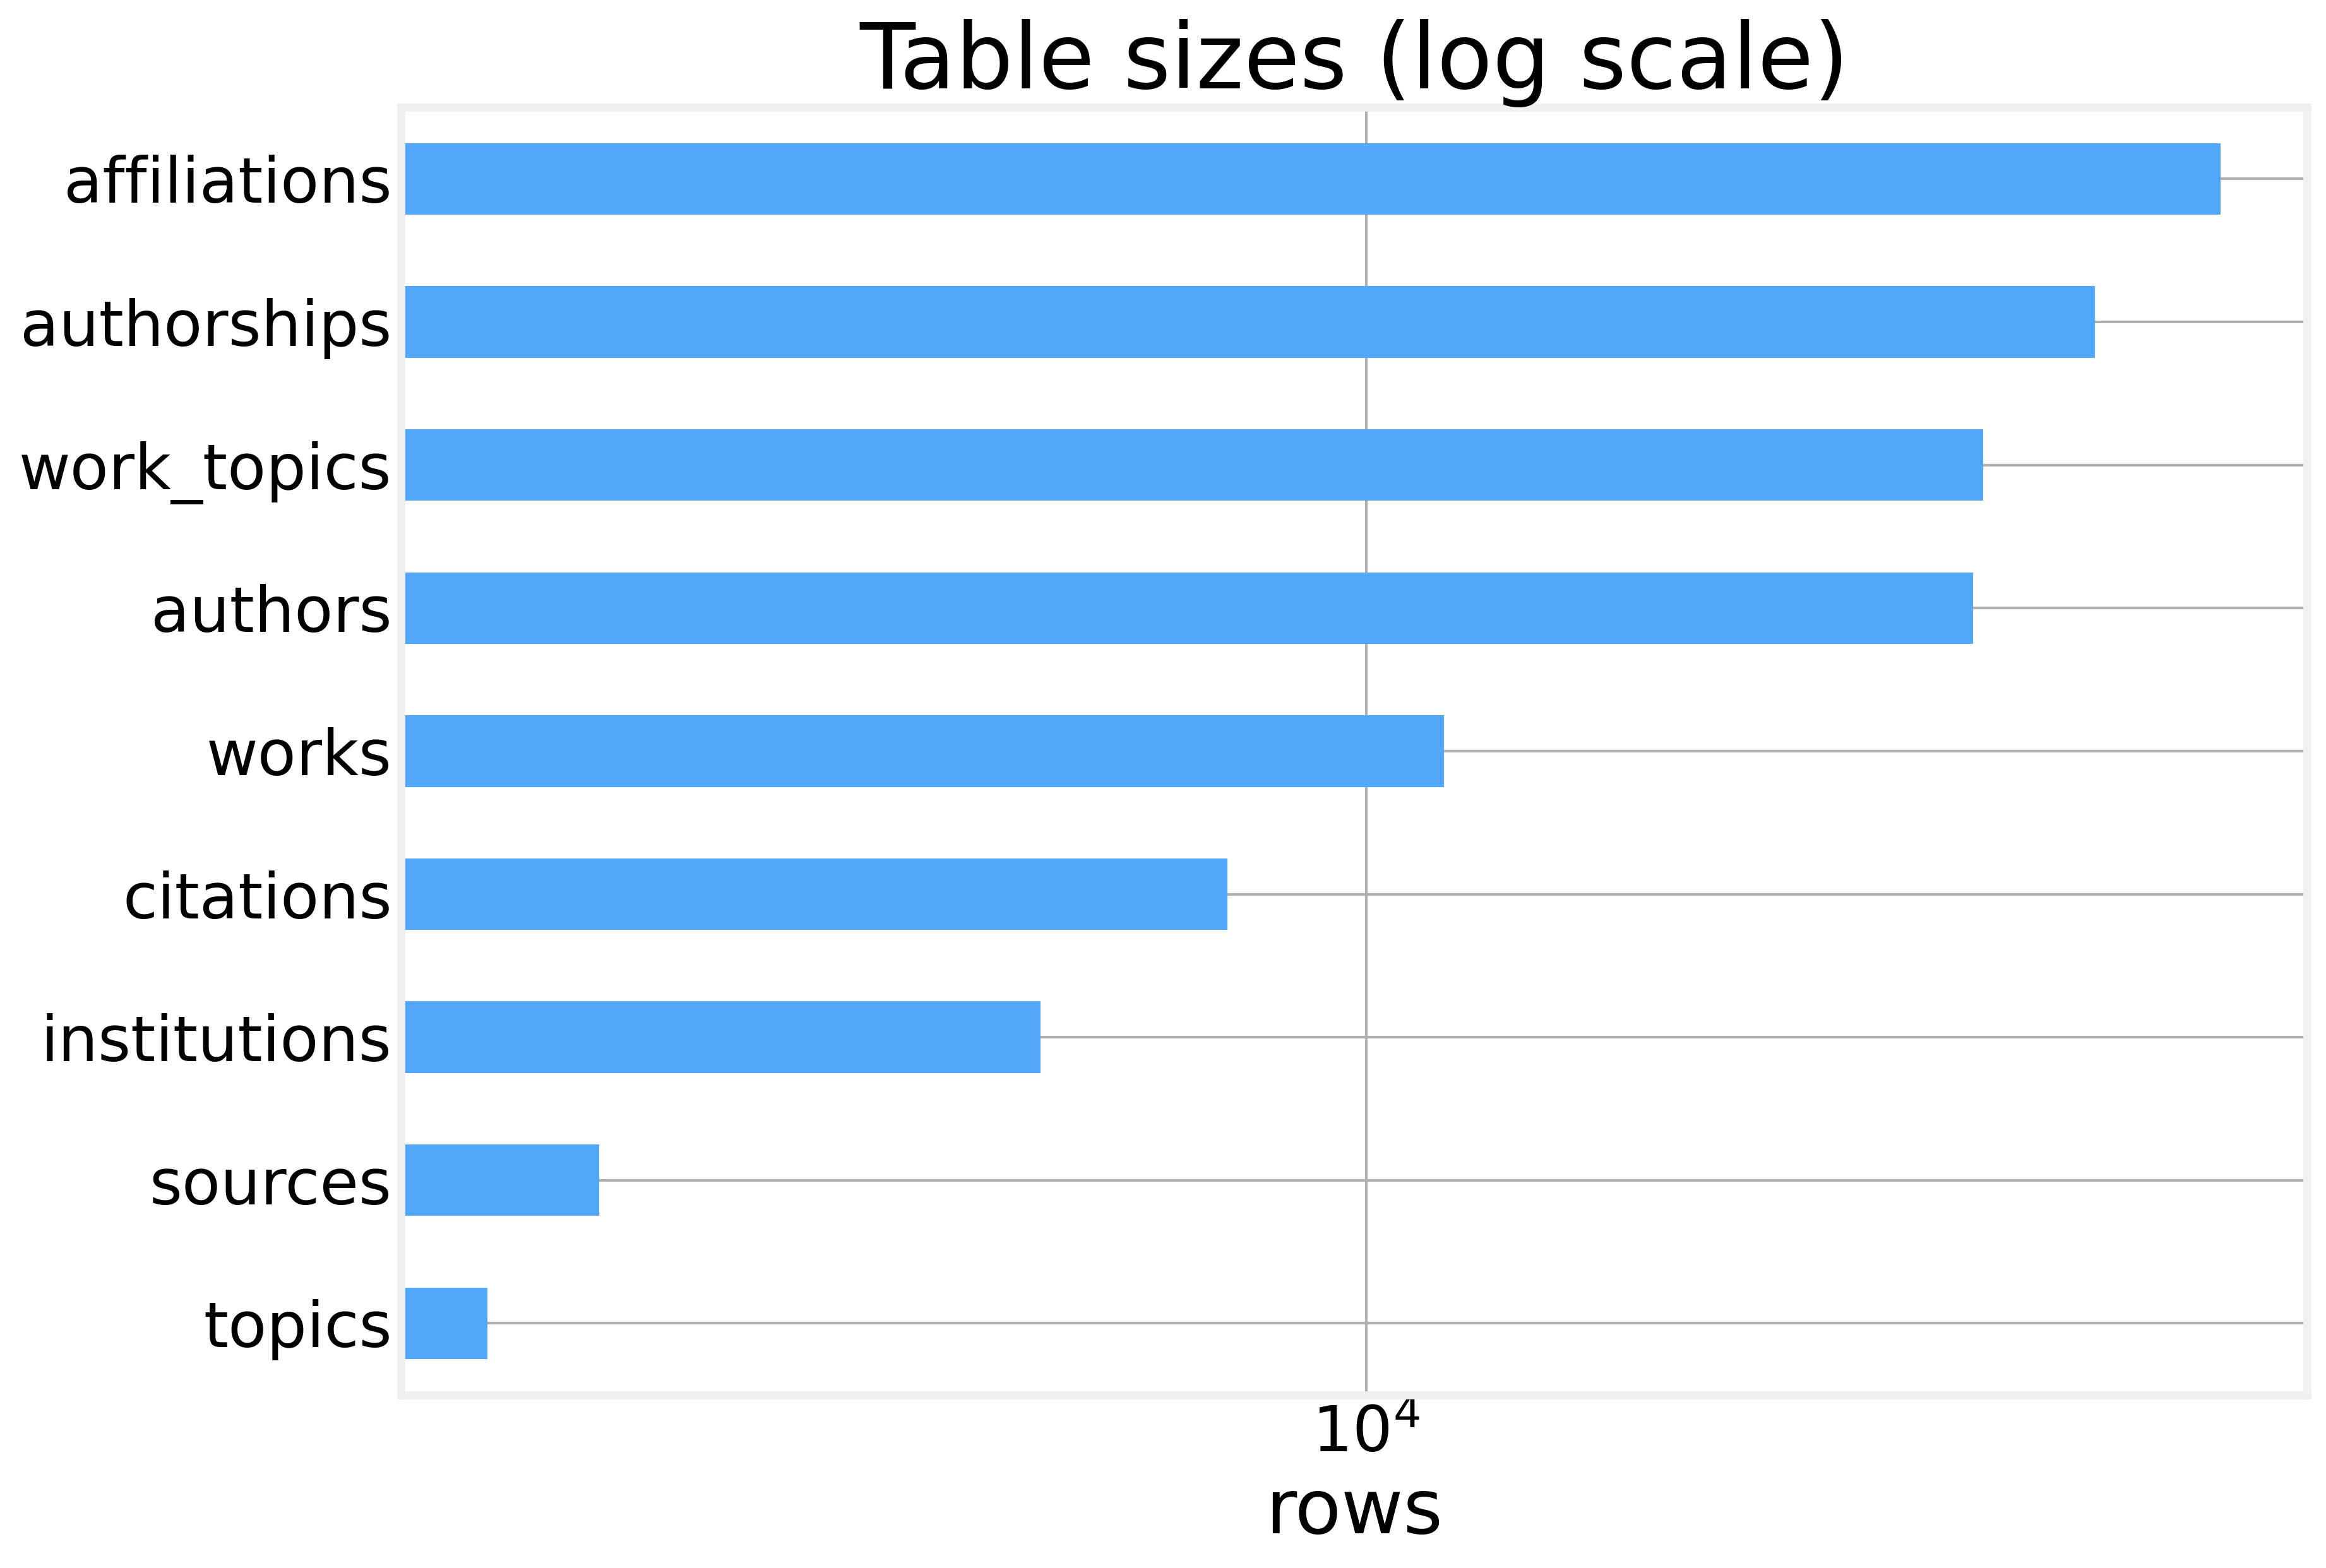

In [13]:
tables = ["works", "authors", "institutions", "sources", "topics",
          "authorships", "affiliations", "work_topics", "citations"]
counts = pd.Series(
    {t: conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
     for t in tables}, name="rows")
print(counts.to_string())

fig, ax = plt.subplots()
counts.sort_values().plot.barh(ax=ax, color=colors[0])
ax.set_xlabel("rows")
ax.set_xscale("log")
ax.set_title("Table sizes (log scale)")
fig.tight_layout()

Entity/link ratios are the first sanity check: authorships should exceed works (papers have multiple authors), affiliations should be same order as authorships, and citations should be *small* — most references point outside our topical slice. If citations were comparable to `works × mean references`, our subset filter didn't do its job.

### 3.2 Works per year

Two things to read off this plot: the growth profile of the field (is our topic exploding, plateauing?), and the **right-censoring of the final year** — a partial year always looks like a collapse. An agent asked "is the field shrinking?" will fall straight into that artifact unless we know it's there.

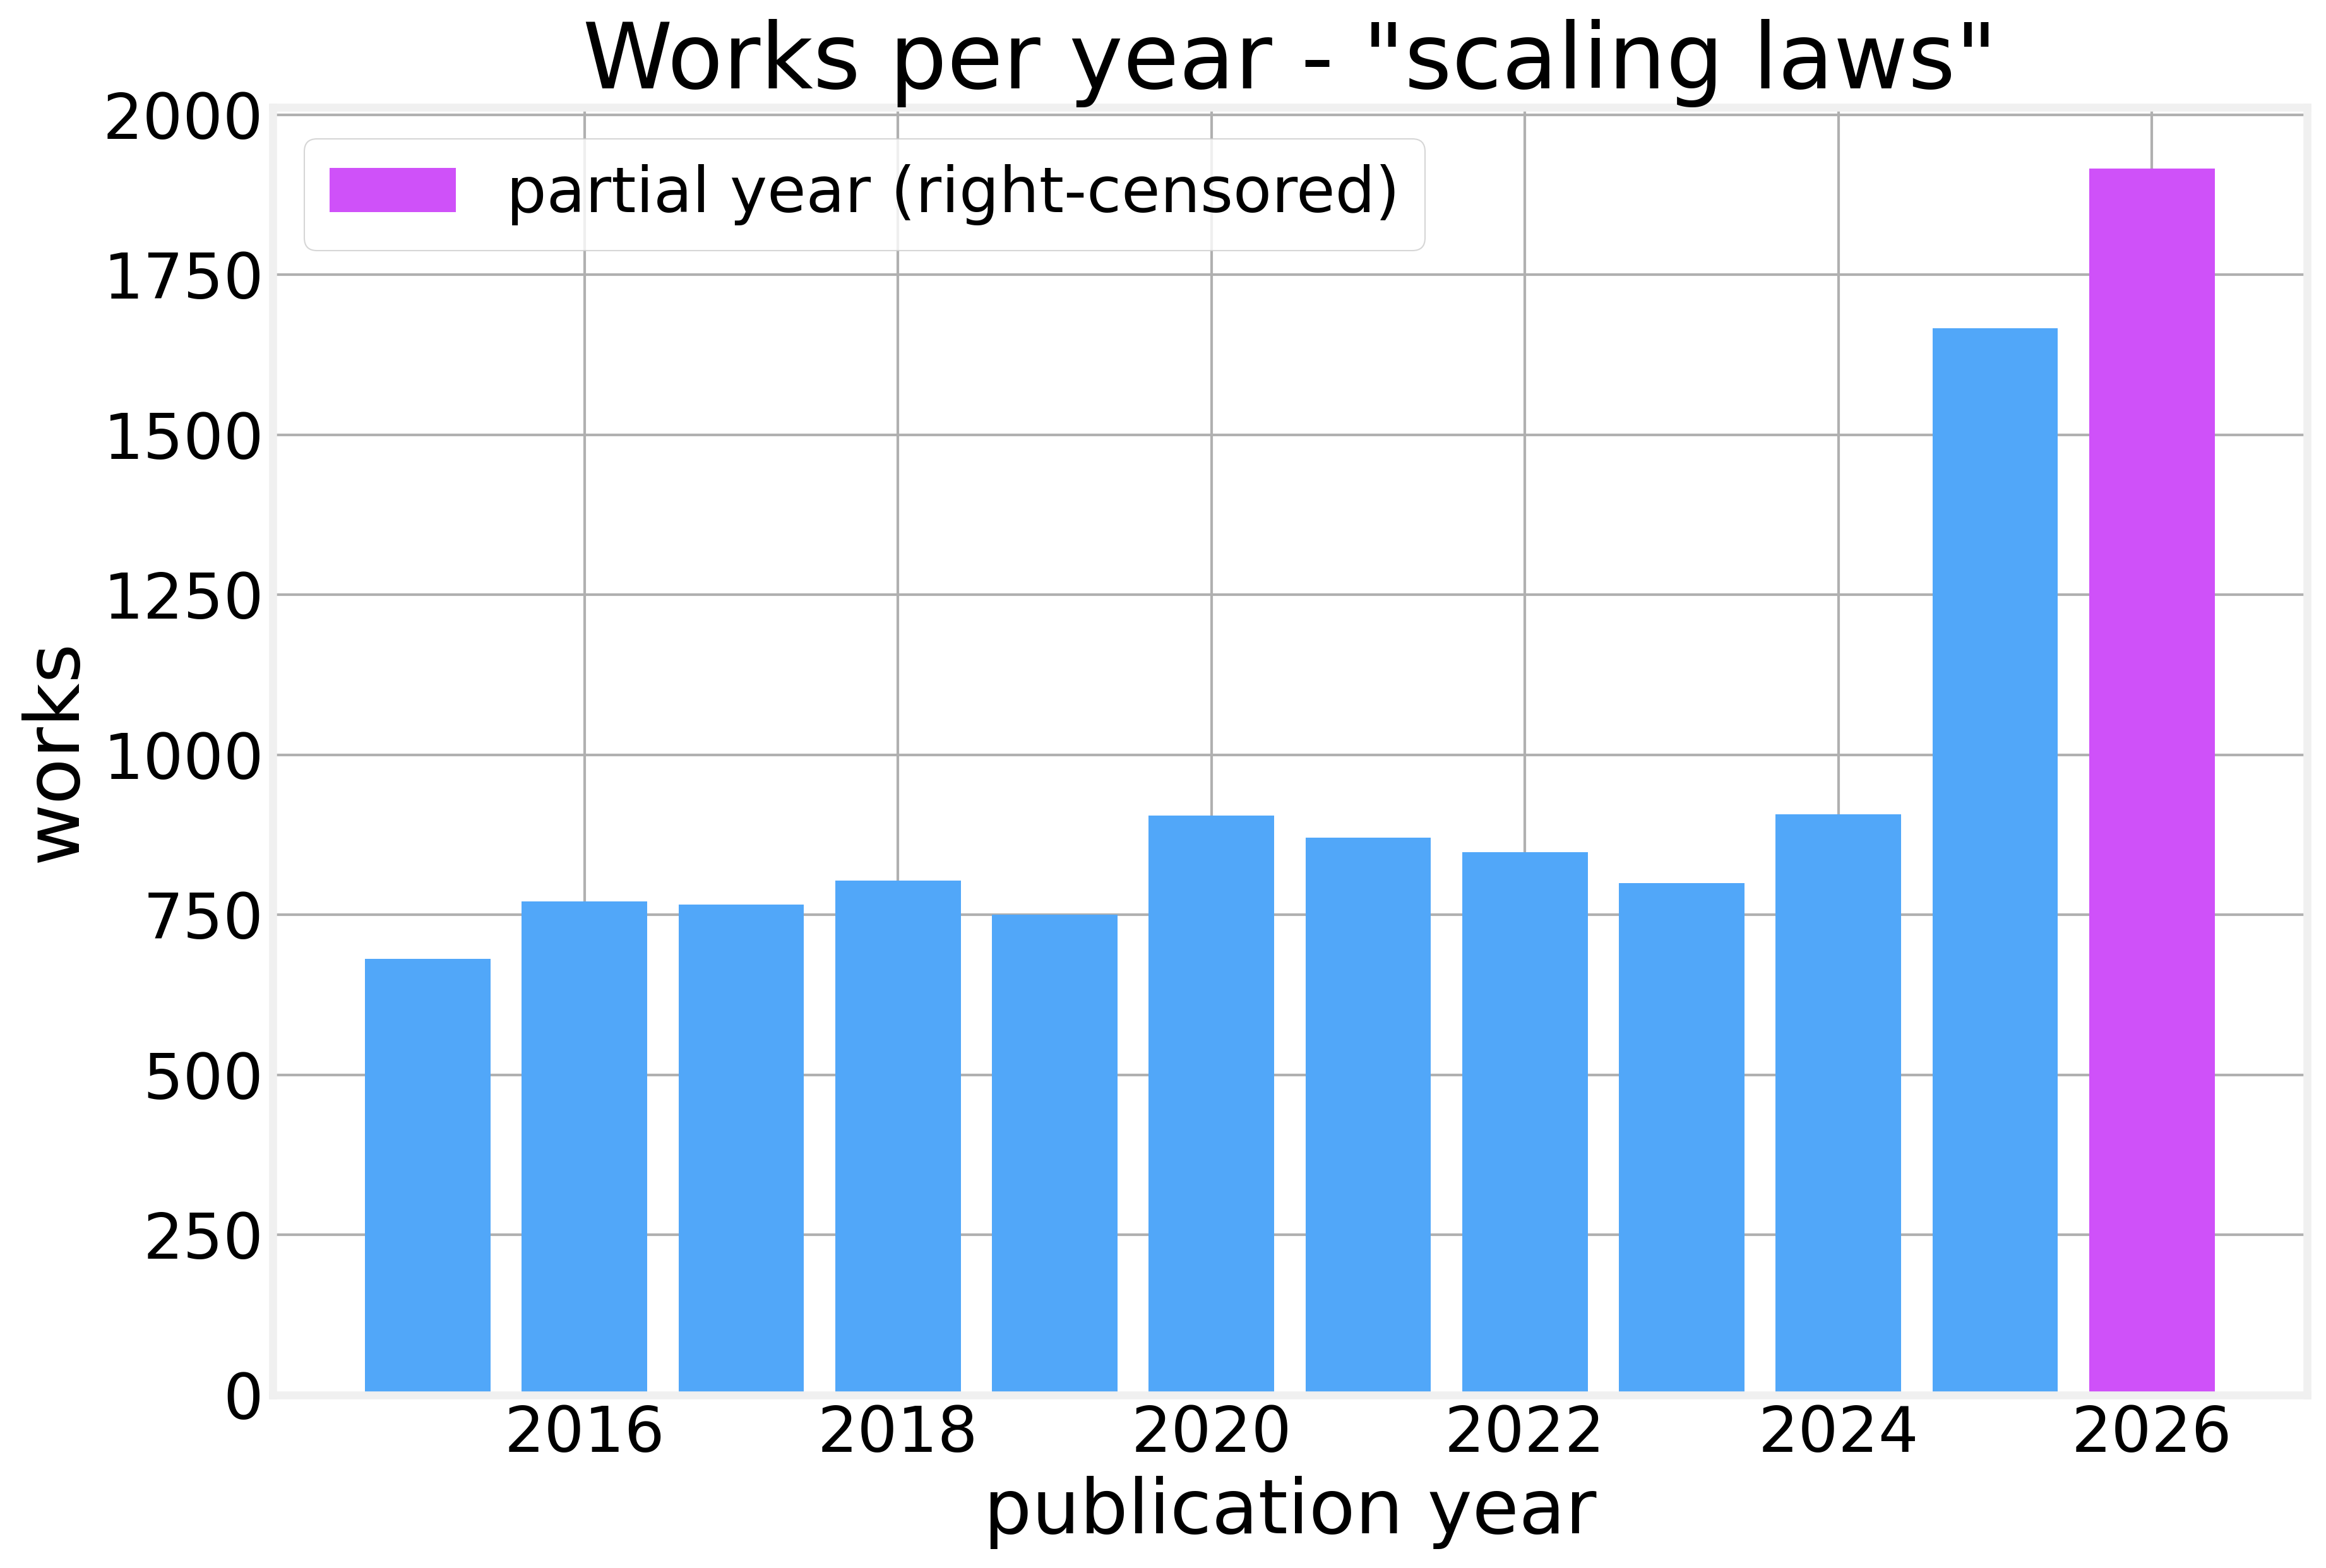

In [14]:
per_year = q("""SELECT publication_year AS year, COUNT(*) AS works
                FROM works
                WHERE publication_year IS NOT NULL
                GROUP BY 1 ORDER BY 1""")

fig, ax = plt.subplots()
ax.bar(per_year["year"], per_year["works"], color=colors[0])
ax.bar(per_year["year"].iloc[-1], per_year["works"].iloc[-1],
       color=colors[1], label="partial year (right-censored)")
ax.set_xlabel("publication year")
ax.set_ylabel("works")
ax.set_title(f"Works per year - {SEARCH_QUERY}")
ax.legend()
fig.tight_layout()

### 3.3 Where is this literature published?

Venue concentration, and a data-model lesson: OpenAlex indexes preprint servers as sources too, so expect arXiv to rank high for anything ML-adjacent. `type` distinguishes journals from repositories from conferences — worth showing because an agent asked about "journals" should not count arXiv as one.

/var/folders/8g/hvs2bf_d4pv053525_0cfrz00000gn/T/ipykernel_39899/373363867.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


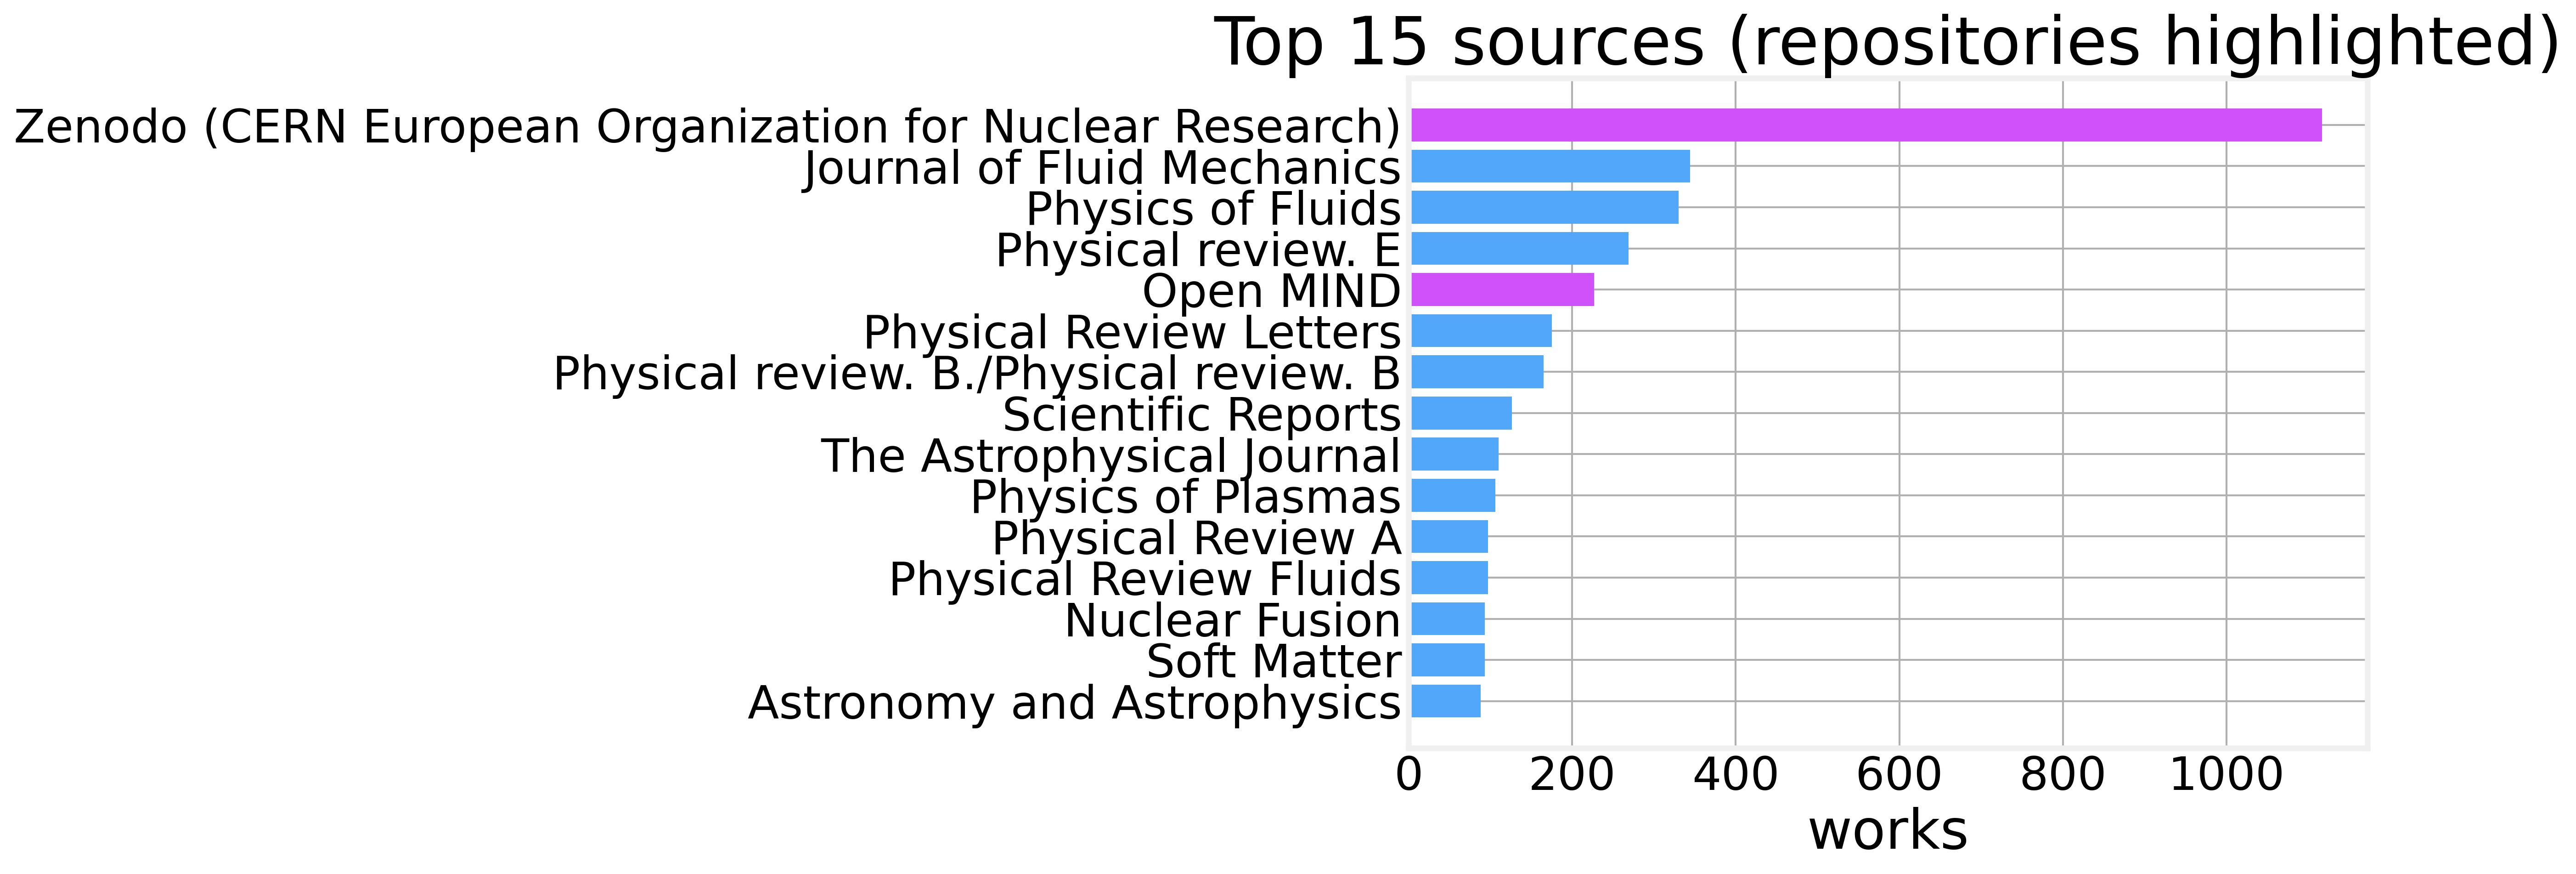

In [15]:
top_sources = q("""SELECT s.display_name AS source, s.type,
                          COUNT(*) AS works
                   FROM works w JOIN sources s ON s.id = w.source_id
                   GROUP BY s.id ORDER BY works DESC LIMIT 15""")

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = [colors[1] if t == "repository" else colors[0]
              for t in top_sources["type"]]
ax.barh(top_sources["source"][::-1], top_sources["works"][::-1],
        color=bar_colors[::-1])
ax.set_xlabel("works")
ax.set_title("Top 15 sources (repositories highlighted)")
fig.tight_layout()

### 3.4 Top institutions — and the double-counting trap

The naive query joins `works → affiliations → institutions` and counts rows. It is **wrong**, and wrong in a way that flatters big labs: a paper with five co-authors at the same institution counts five times. The fix is deduplicating (work, institution) pairs *before* counting — `COUNT(DISTINCT ...)` or a `DISTINCT` subquery.

This trap earns its own subsection because it is exactly the kind of error an agent will make: the naive SQL is syntactically fine, runs fast, and returns plausible numbers. The only defense is knowing the data model — which is why our server will expose `describe_table` with foreign keys, and why this notebook exists.

In [16]:
naive = q("""SELECT i.display_name AS institution, COUNT(*) AS n
             FROM affiliations a
             JOIN institutions i ON i.id = a.institution_id
             GROUP BY i.id ORDER BY n DESC LIMIT 10""")

correct = q("""SELECT i.display_name AS institution,
                      COUNT(DISTINCT a.work_id) AS n
               FROM affiliations a
               JOIN institutions i ON i.id = a.institution_id
               GROUP BY i.id ORDER BY n DESC LIMIT 10""")

comparison = naive.merge(correct, on="institution", how="outer",
                         suffixes=("_naive", "_dedup")).head(10)
comparison["inflation"] = (comparison["n_naive"]
                           / comparison["n_dedup"]).round(2)
comparison

,institution,n_naive,n_dedup,inflation
0,Centre National de la Recherche Scientifique,1738.0,643.0,2.70
1,Chinese Academy of Sciences,1021.0,283.0,3.61
2,Commissariat à l'Énergie Atomique et aux Énerg...,357.0,124.0,2.88
3,Huazhong University of Science and Technology,299.0,NaN,NaN
4,Massachusetts Institute of Technology,NaN,122.0,NaN
5,Peking University,356.0,144.0,2.47
6,Shanghai Jiao Tong University,342.0,117.0,2.92
7,Tsinghua University,590.0,216.0,2.73
8,University of Chinese Academy of Sciences,511.0,173.0,2.95
9,University of Science and Technology of China,497.0,160.0,3.11


/var/folders/8g/hvs2bf_d4pv053525_0cfrz00000gn/T/ipykernel_39899/1028827777.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


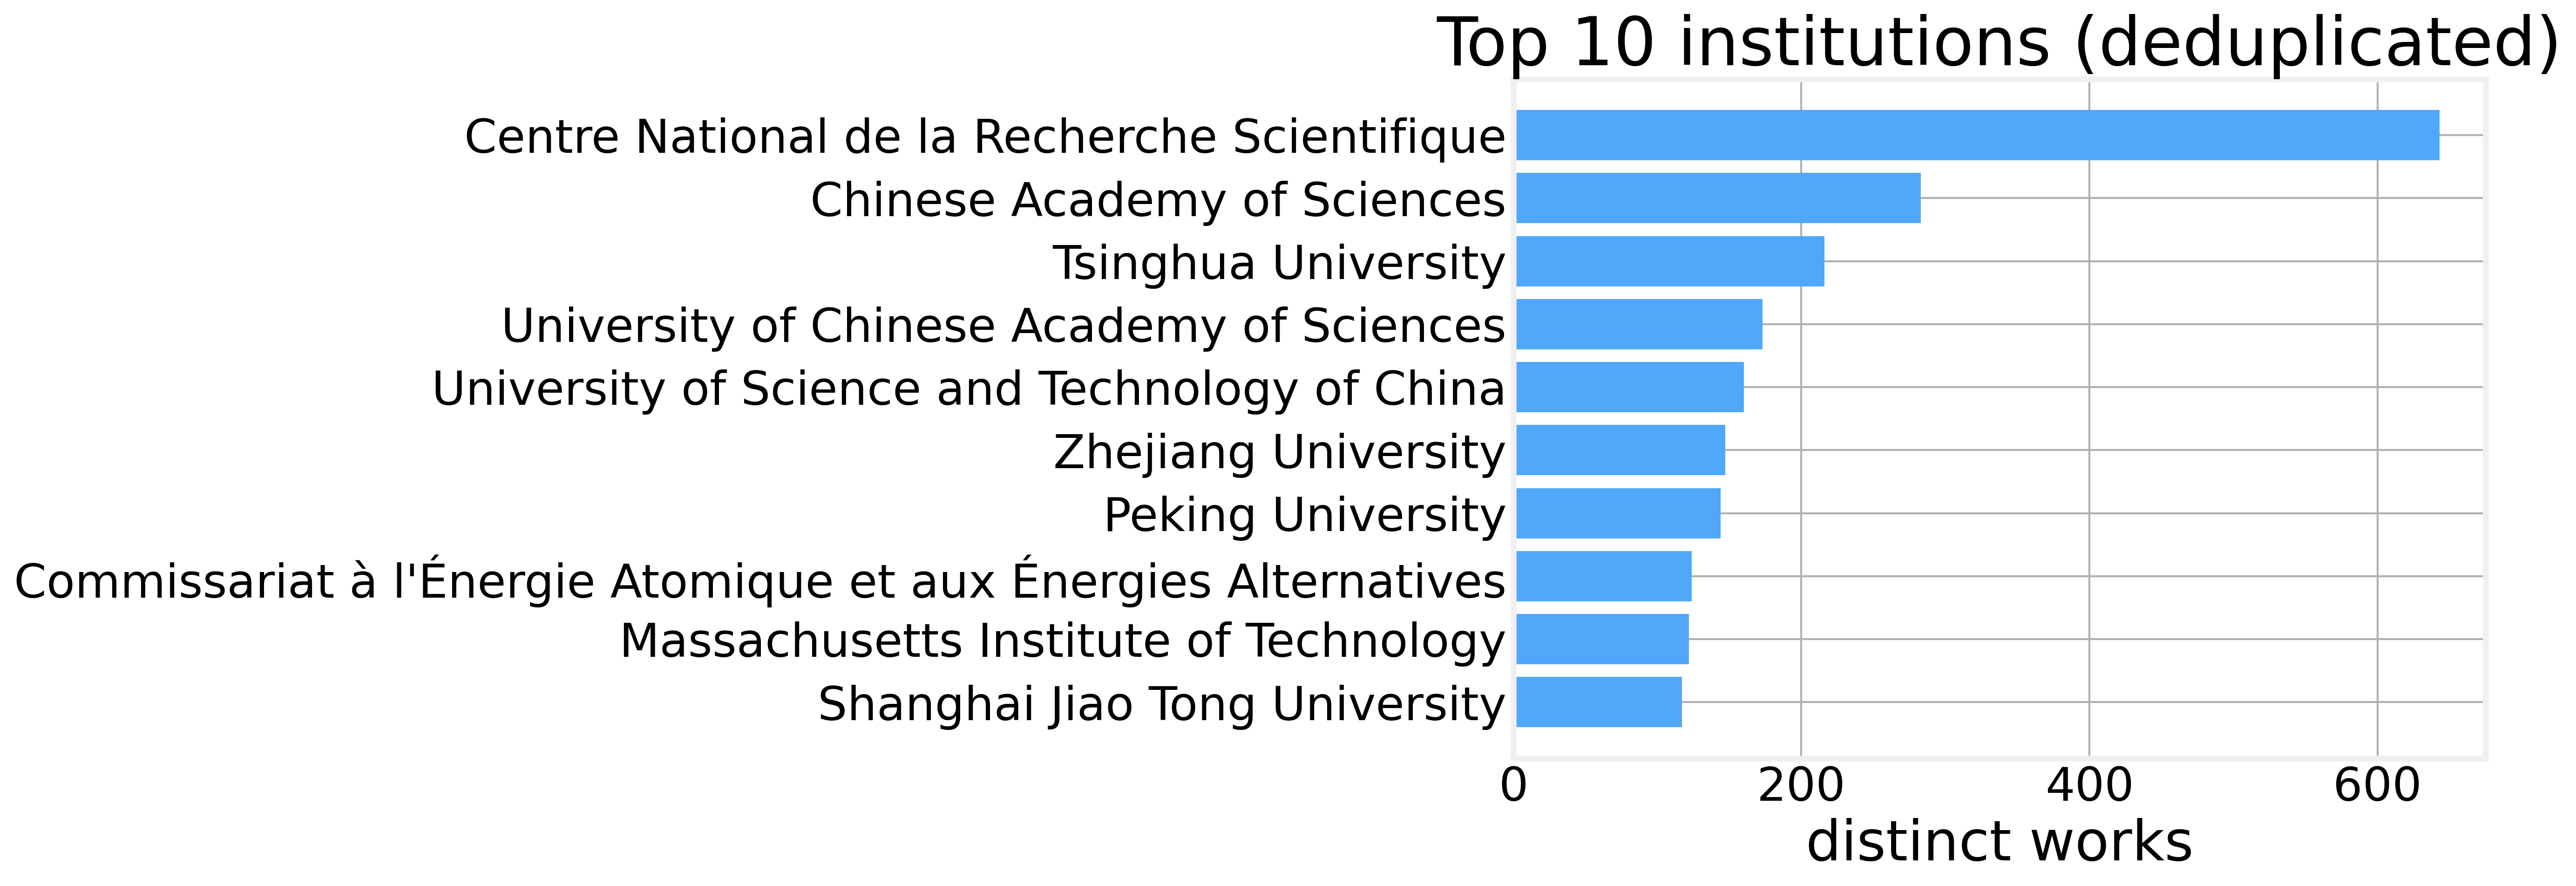

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(correct["institution"][::-1], correct["n"][::-1], color=colors[0])
ax.set_xlabel("distinct works")
ax.set_title("Top 10 institutions (deduplicated)")
fig.tight_layout()

### 3.5 Team sizes

How many authors does a paper in this corpus have? Count distributions like this are heavy-tailed, and for heavy tails a histogram is the wrong instrument: linear bins bury the tail, log bins introduce binning choices, and the extreme values — the most interesting part — turn into single-count noise.

The **CCDF** (complementary cumulative distribution, \(P(X \ge x)\)) needs no binning at all: sort the values and plot rank against value on log-log axes. Every point is data; the tail is readable directly. We'll reuse this helper for every heavy-tailed quantity below.

count    10862.00
mean         3.97
std          3.67
min          1.00
25%          2.00
50%          3.00
75%          5.00
max        100.00

largest team: 100 authors - hyperauthorship exists even in a topical slice


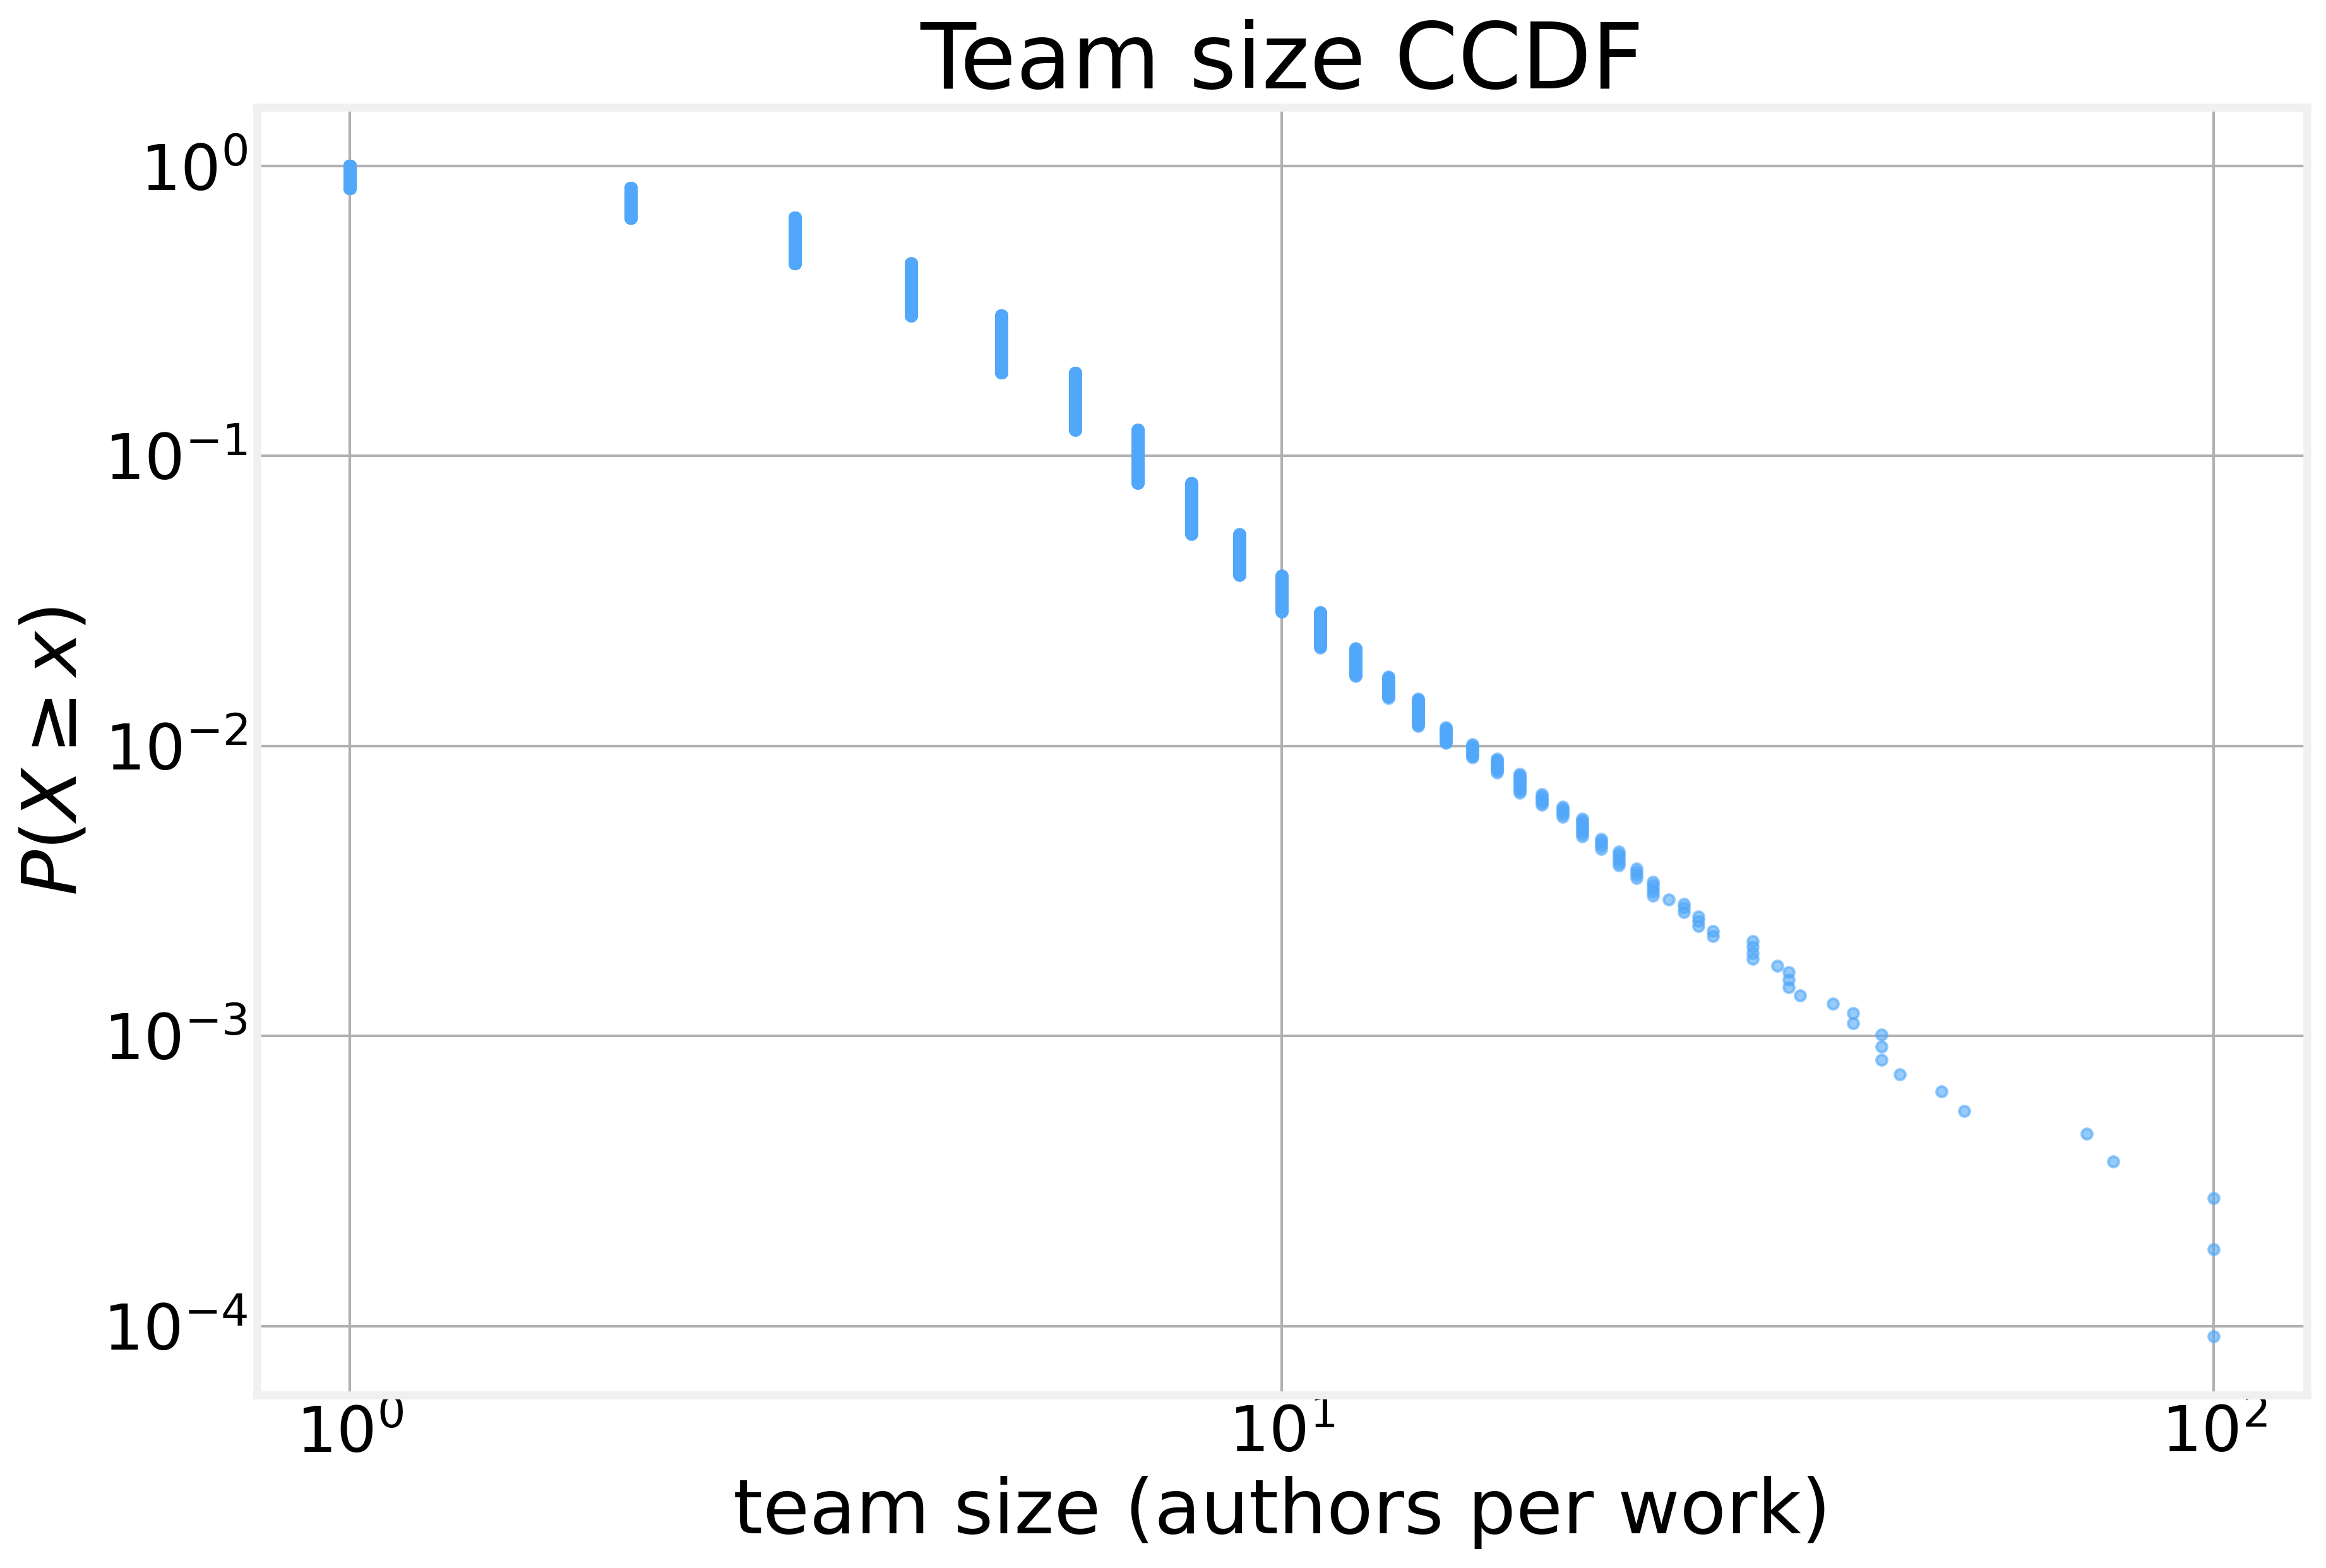

In [18]:
def ccdf(values):
    """P(X >= x) without binning: sorted values vs. normalized rank."""
    x = np.sort(np.asarray(values))
    y = 1.0 - np.arange(len(x)) / len(x)
    return x, y


team = q("""SELECT COUNT(*) AS n_authors
            FROM authorships GROUP BY work_id""")["n_authors"]

fig, ax = plt.subplots()
x, y = ccdf(team)
ax.loglog(x, y, marker="o", linestyle="none", markersize=4,
          color=colors[0], alpha=0.6)
ax.set_xlabel("team size (authors per work)")
ax.set_ylabel(r"$P(X \geq x)$")
ax.set_title("Team size CCDF")
fig.tight_layout()

print(team.describe().round(2).to_string())
print(f"\nlargest team: {int(team.max())} authors "
      "- hyperauthorship exists even in a topical slice")

### 3.6 Citations: two counts, two meanings

Each work carries **two** citation numbers now, and conflating them is the subtlest trap in this database:

* `cited_by_count` — OpenAlex's *global* count: citations from anywhere in the catalog.
* in-degree in our `citations` table — citations *from within this subset only*, by construction of the closed world.

The gap between the curves below is the boundary of our world made visible. An agent asked "what's the most cited paper?" gets a defensible answer from either — but "how many citations does it have?" must come from the global count, and *"who cites it?"* can only be answered internally. Knowing which question maps to which column is precisely the context a good tool description should carry.

zero global citations: 29.1% of works
zero internal citations: 74.5% of works


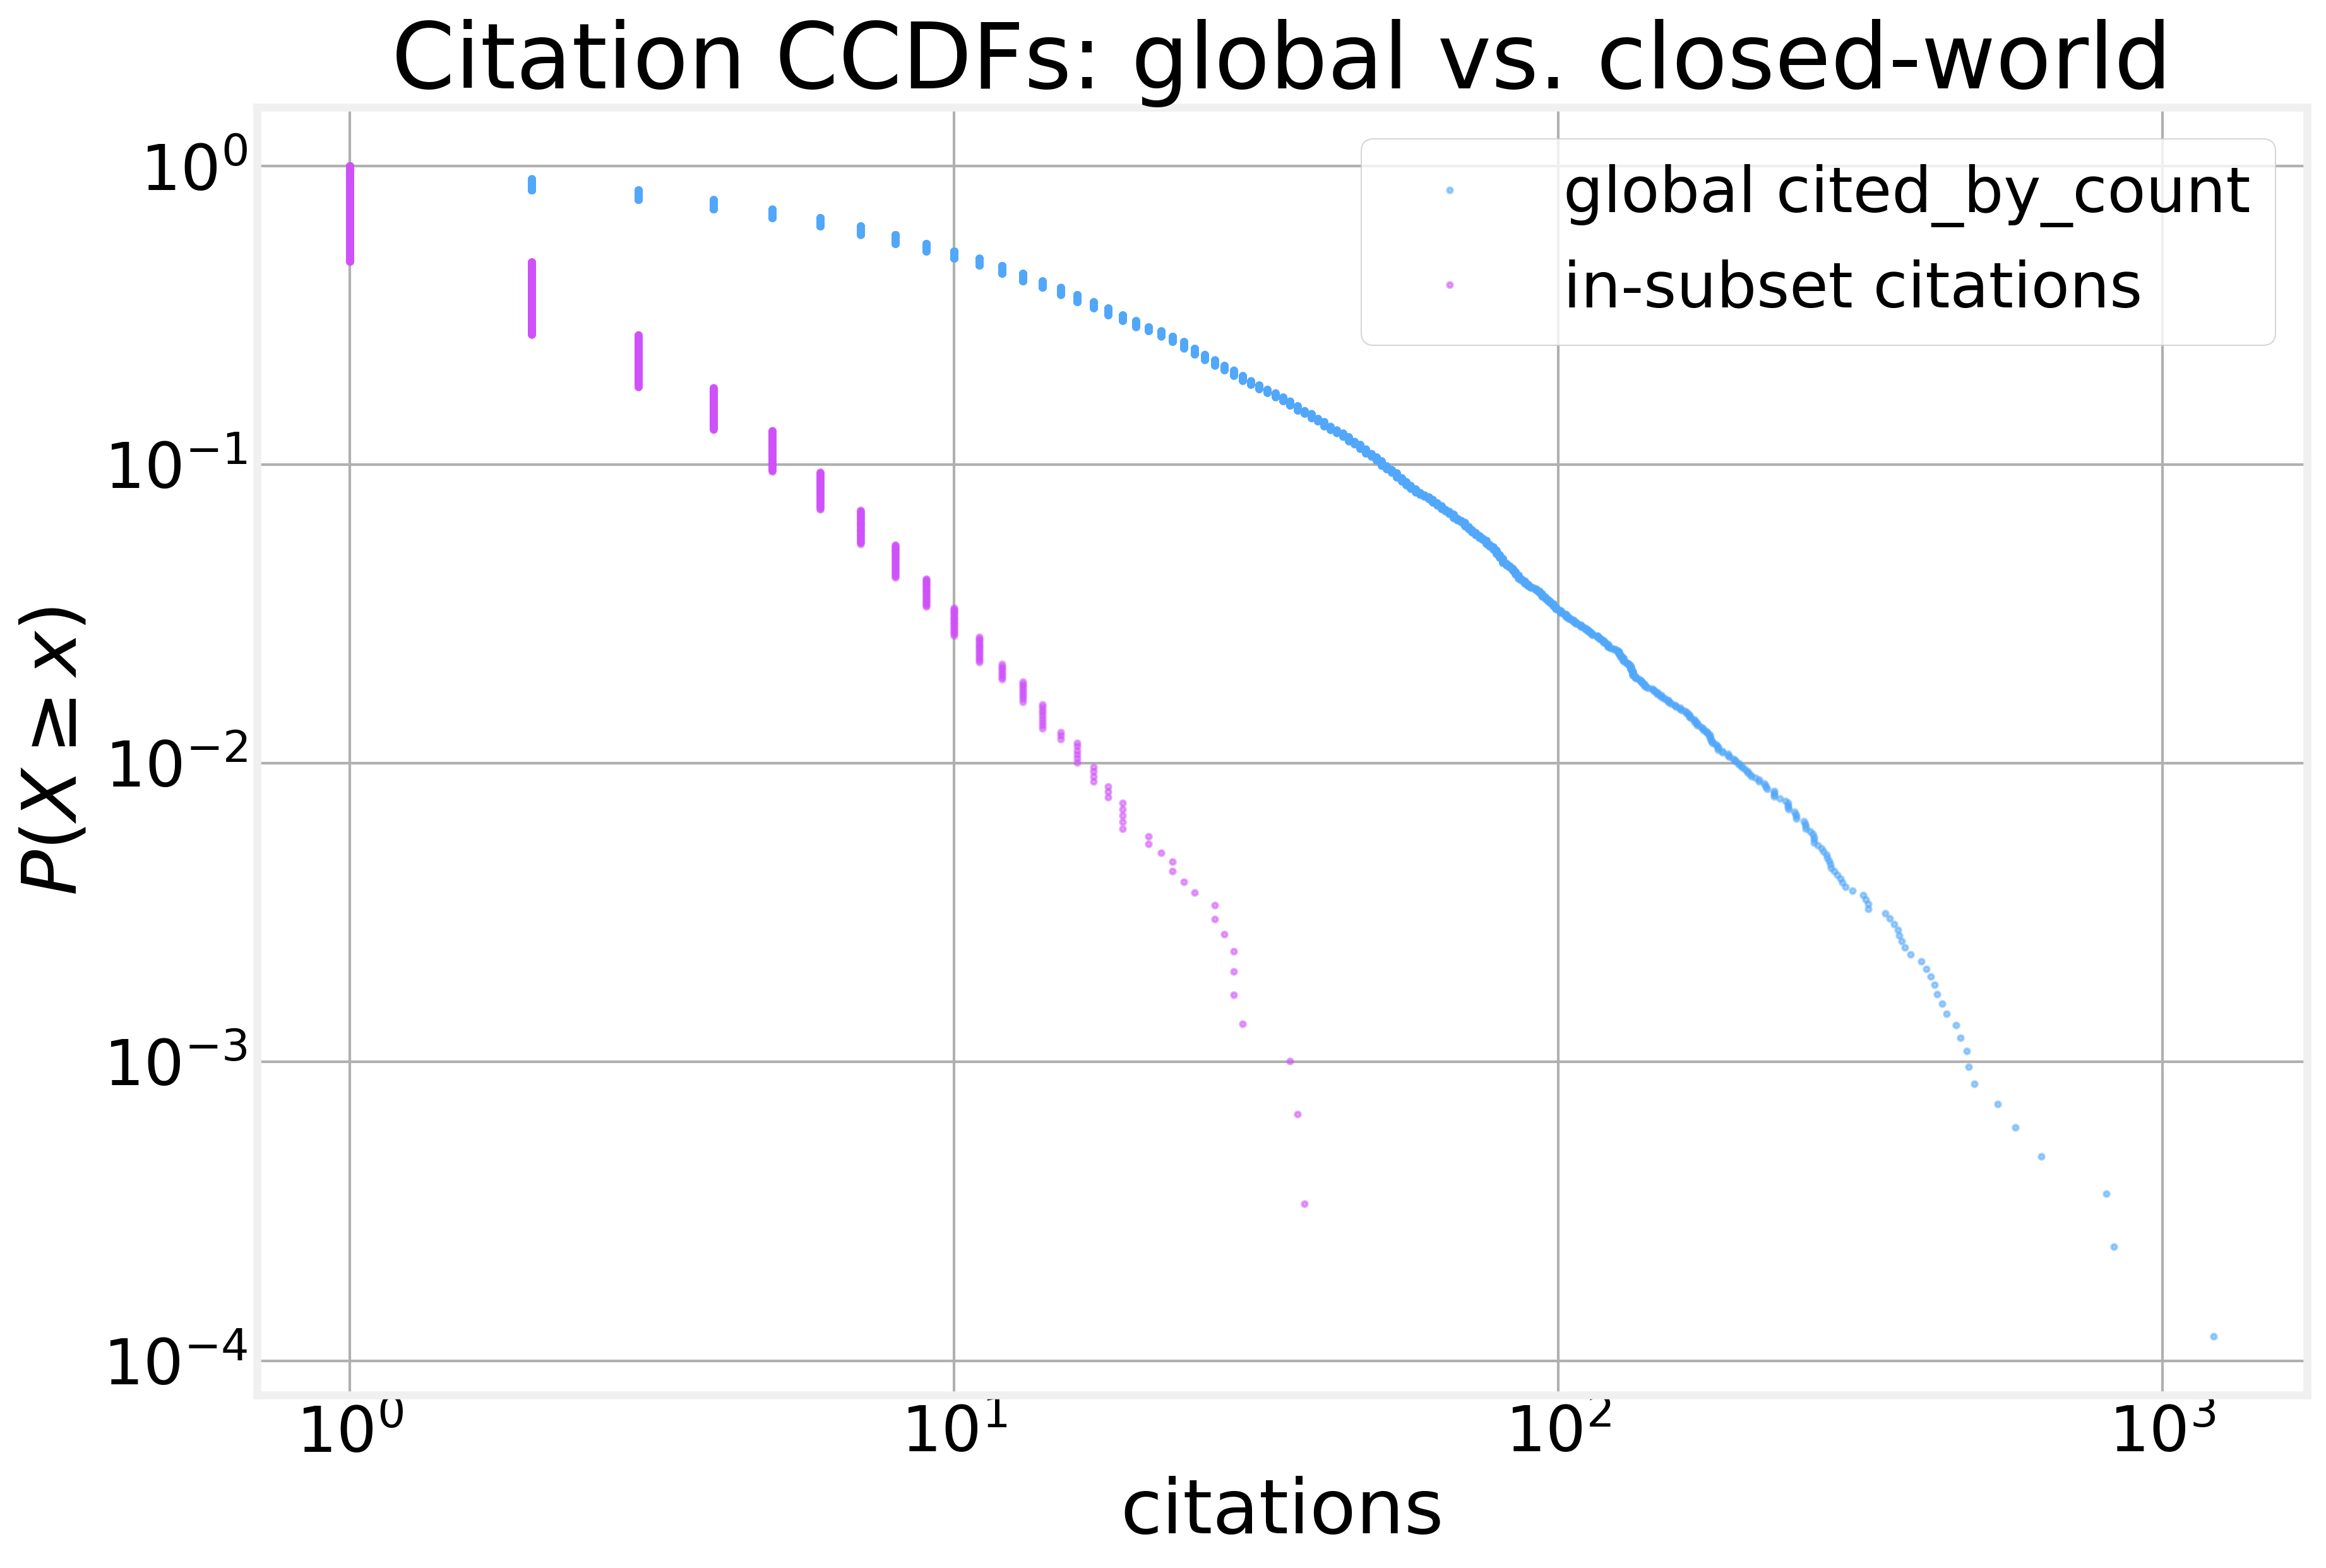

In [19]:
global_cites = q("SELECT cited_by_count AS c FROM works")["c"]
internal = q("""SELECT COUNT(c.citing_id) AS c
                FROM works w
                LEFT JOIN citations c ON c.cited_id = w.id
                GROUP BY w.id""")["c"]

fig, ax = plt.subplots()
for series, label, color in [(global_cites, "global cited_by_count",
                              colors[0]),
                             (internal, "in-subset citations", colors[1])]:
    vals = series[series > 0]
    x, y = ccdf(vals)
    ax.loglog(x, y, marker=".", linestyle="none", markersize=4,
              alpha=0.5, color=color, label=label)
ax.set_xlabel("citations")
ax.set_ylabel(r"$P(X \geq x)$")
ax.set_title("Citation CCDFs: global vs. closed-world")
ax.legend()
fig.tight_layout()

print(f"zero global citations: {(global_cites == 0).mean():.1%} of works")
print(f"zero internal citations: {(internal == 0).mean():.1%} of works")

### 3.7 The collaboration graph

The coauthorship network, summarized by its degree distribution: for each author, how many *distinct* coauthors within the corpus? The self-join on `authorships` builds the pair list; the threshold excludes mega-collaborations first, because a single 500-author paper mints ~125,000 pairwise edges — one clique from one paper would dominate the entire distribution. Thresholding at 50 is a judgment call; the honest move is making it explicit and stating it.

authors in graph: 32,328; median degree 5, max 78


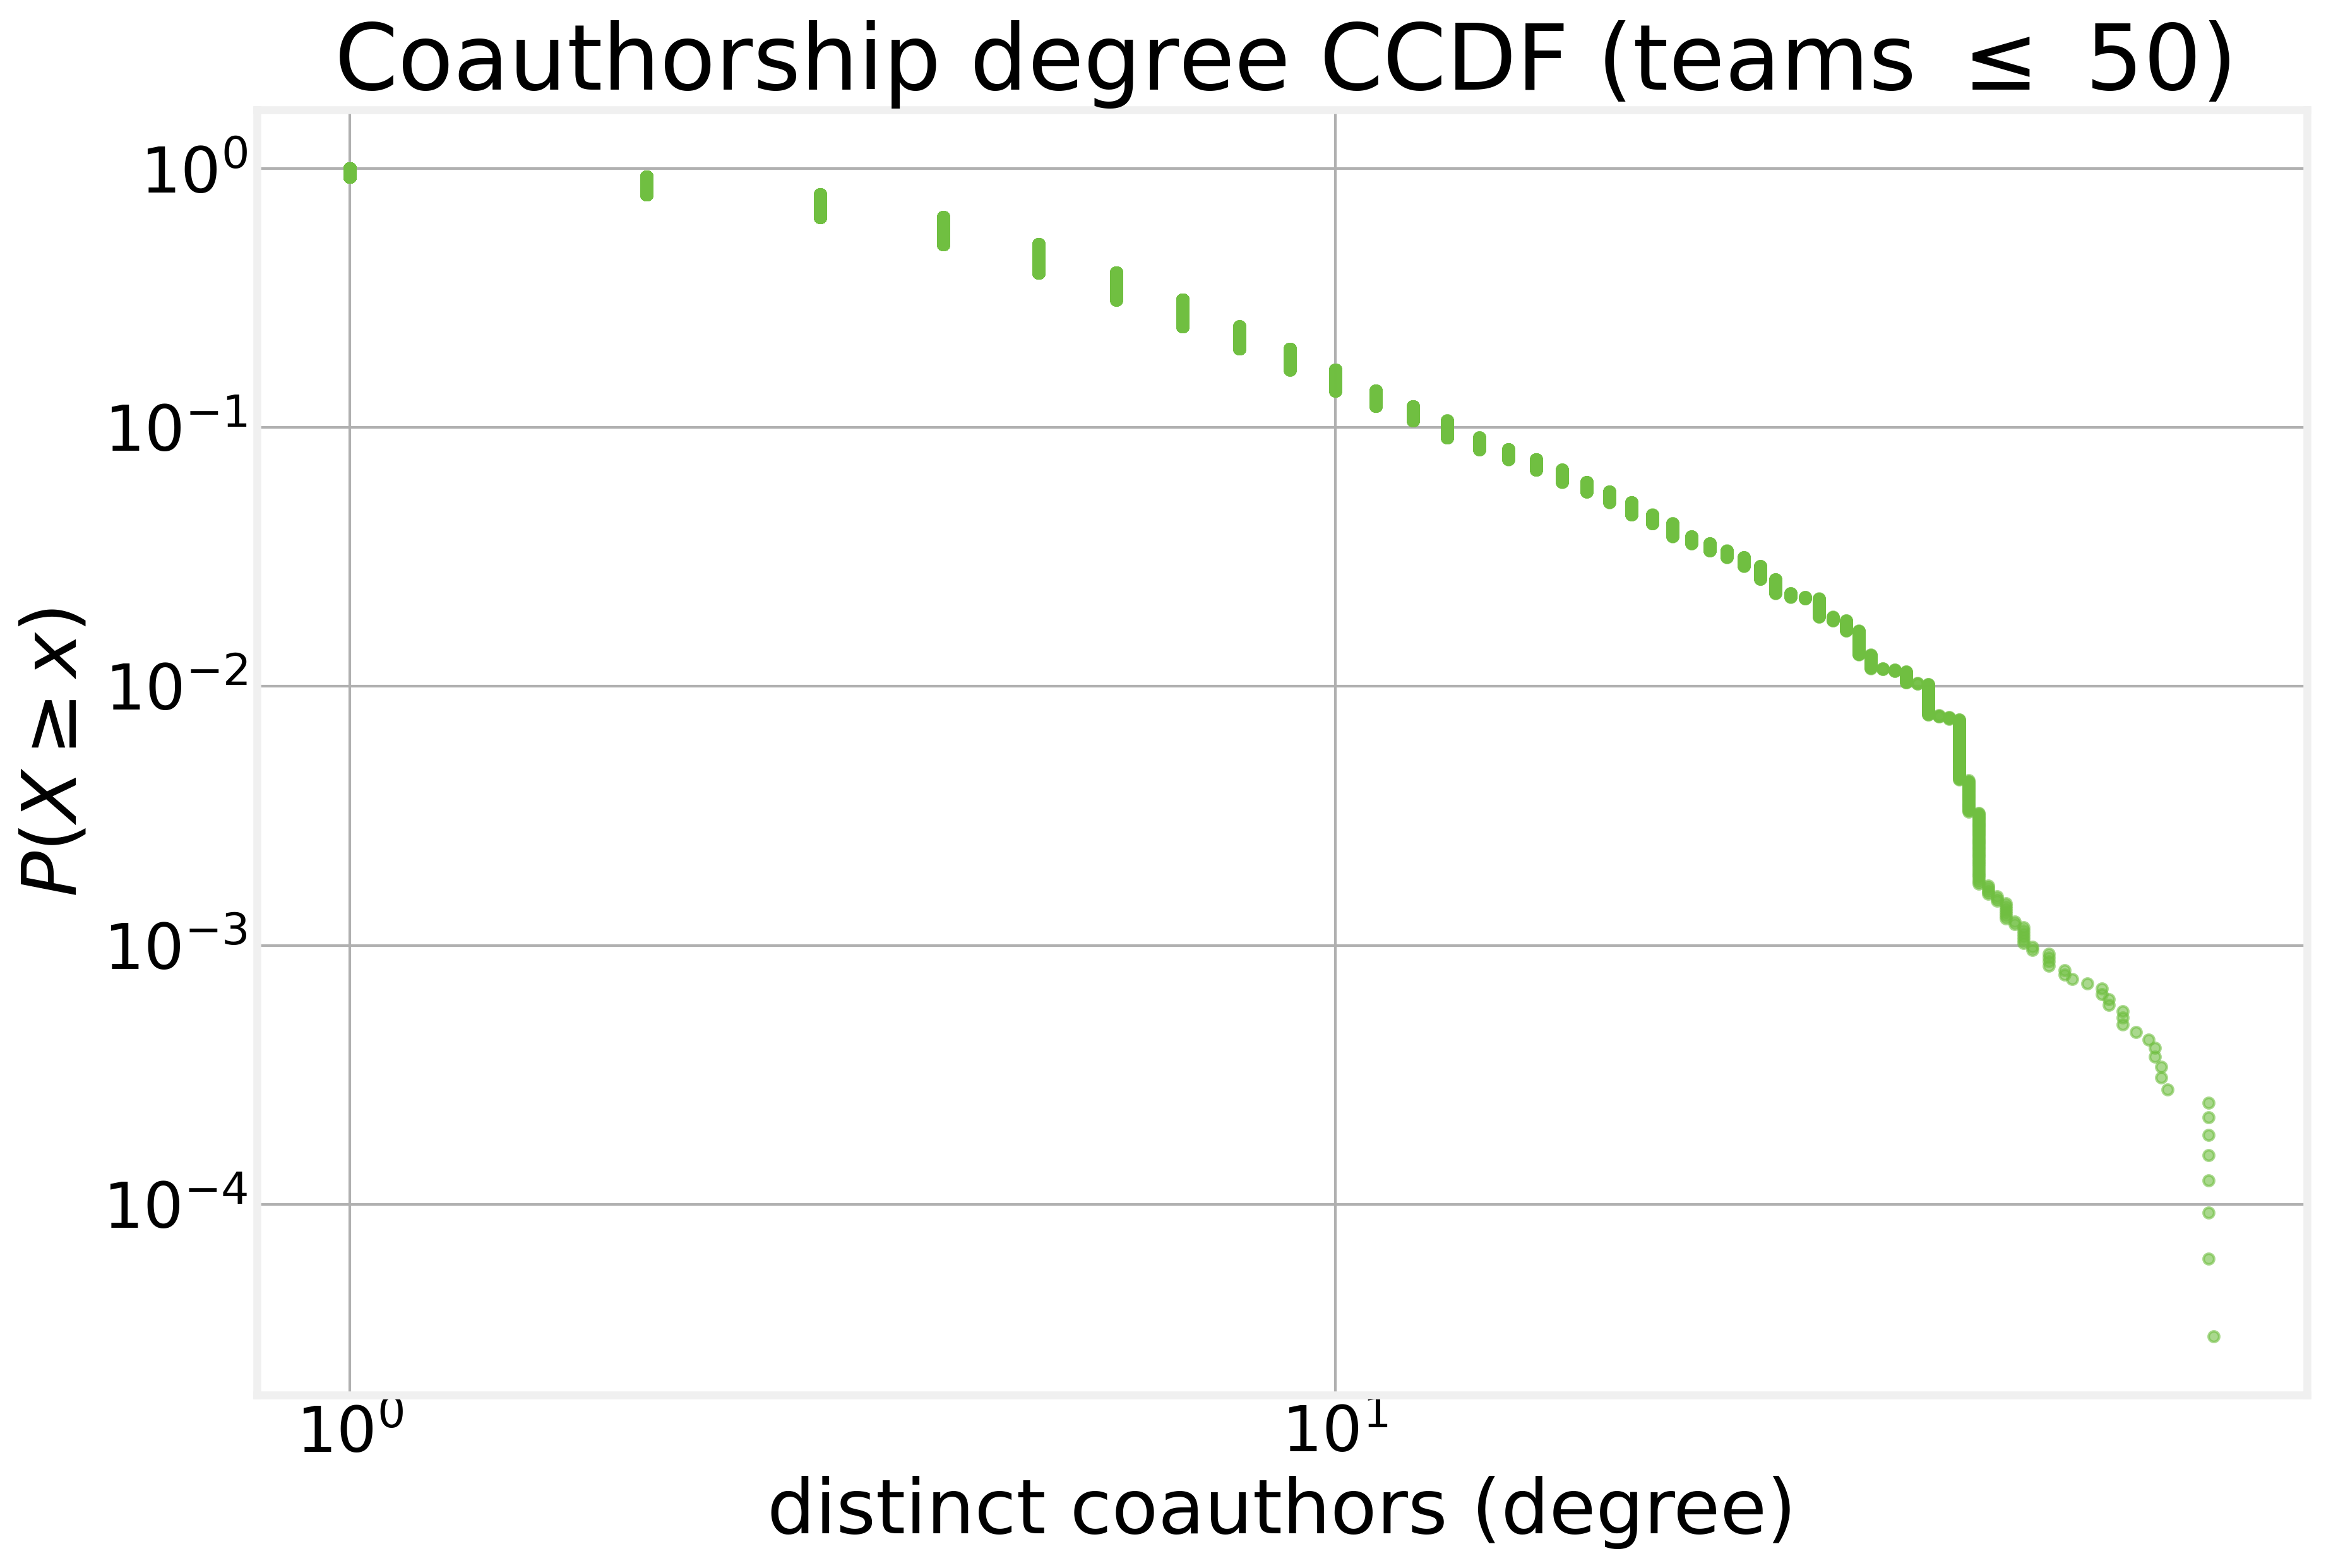

In [20]:
degrees = q("""
    WITH small AS (
        SELECT work_id FROM authorships
        GROUP BY work_id HAVING COUNT(*) <= 50
    )
    SELECT a1.author_id, COUNT(DISTINCT a2.author_id) AS degree
    FROM authorships a1
    JOIN authorships a2
      ON a1.work_id = a2.work_id AND a1.author_id != a2.author_id
    WHERE a1.work_id IN (SELECT work_id FROM small)
    GROUP BY a1.author_id""")["degree"]

fig, ax = plt.subplots()
x, y = ccdf(degrees)
ax.loglog(x, y, marker="o", linestyle="none", markersize=4,
          color=colors[2], alpha=0.6)
ax.set_xlabel("distinct coauthors (degree)")
ax.set_ylabel(r"$P(X \geq x)$")
ax.set_title(r"Coauthorship degree CCDF (teams $\leq$ 50)")
fig.tight_layout()

print(f"authors in graph: {len(degrees):,}; "
      f"median degree {degrees.median():.0f}, max {degrees.max():,}")

### 3.8 International collaboration

Fraction of works with authors in at least two countries, by year — a four-table question (`works`, `affiliations`, `institutions`, plus the dedup) answered in one CTE. Note the same dedup discipline as 3.4: distinct (work, country) pairs first, then count.

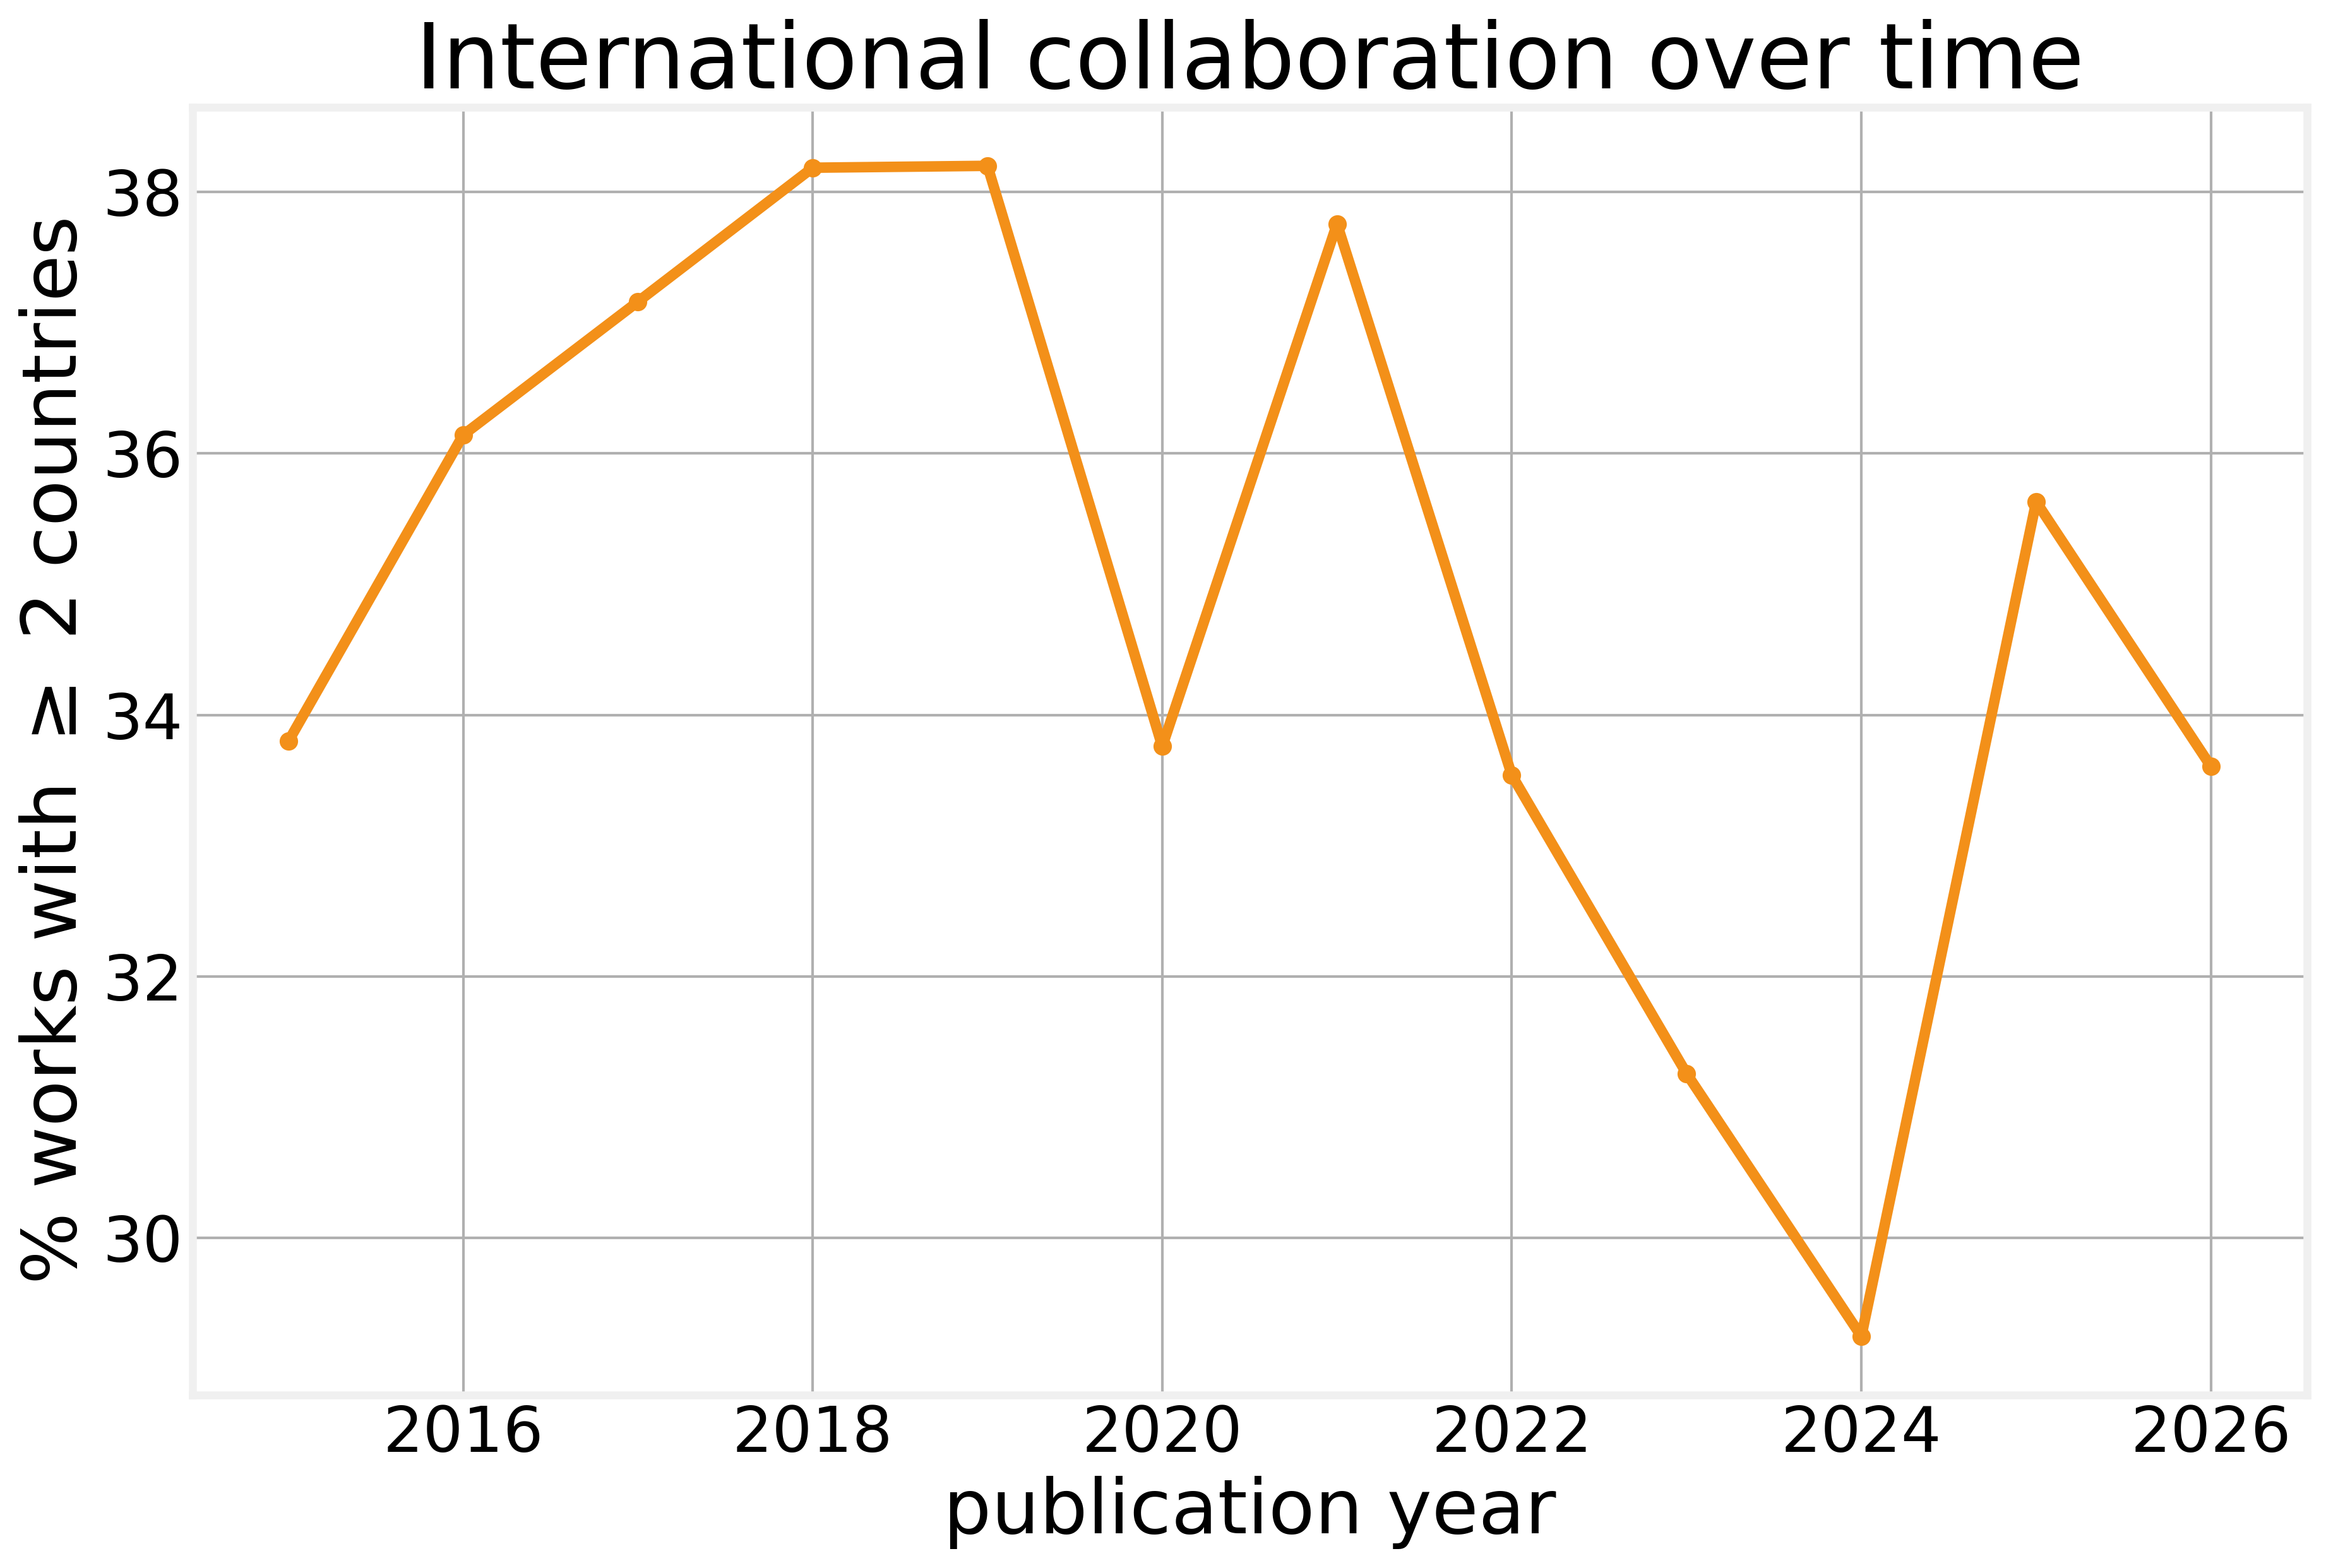

In [21]:
intl = q("""
    WITH wc AS (
        SELECT DISTINCT a.work_id, i.country_code
        FROM affiliations a
        JOIN institutions i ON i.id = a.institution_id
        WHERE i.country_code IS NOT NULL
    ),
    per_work AS (
        SELECT work_id, COUNT(*) AS n_countries FROM wc GROUP BY work_id
    )
    SELECT w.publication_year AS year,
           AVG(CASE WHEN p.n_countries > 1 THEN 1.0 ELSE 0.0 END) AS share,
           COUNT(*) AS works
    FROM per_work p JOIN works w ON w.id = p.work_id
    WHERE w.publication_year IS NOT NULL
    GROUP BY 1 ORDER BY 1""")

fig, ax = plt.subplots()
ax.plot(intl["year"], 100 * intl["share"], marker="o", color=colors[3])
ax.set_xlabel("publication year")
ax.set_ylabel(r"% works with $\geq$ 2 countries")
ax.set_title("International collaboration over time")
fig.tight_layout()

### 3.9 The missing-data audit

The single most important table in this notebook for anyone deploying the server. Every gap below is a question the agent will answer *wrong by omission* — institution rankings silently exclude works whose affiliations didn't resolve; full-text search silently skips works without abstracts. None of this is fixable here; all of it is manageable if known, and the right place to surface it is in tool descriptions and system prompts.

In [22]:
audit = pd.Series({
    "works without abstract":
        q("""SELECT AVG(abstract IS NULL) AS x FROM works""")["x"][0],
    "works with no resolved institution":
        q("""SELECT AVG(id NOT IN
                 (SELECT DISTINCT work_id FROM affiliations)) AS x
             FROM works""")["x"][0],
    "works with no source/venue":
        q("""SELECT AVG(source_id IS NULL) AS x FROM works""")["x"][0],
    "authors without ORCID":
        q("""SELECT AVG(orcid IS NULL) AS x FROM authors""")["x"][0],
    "works with zero global citations":
        q("""SELECT AVG(cited_by_count = 0) AS x FROM works""")["x"][0],
}, name="fraction")

audit.map("{:.1%}".format).to_frame()

,fraction
works without abstract,21.4%
works with no resolved institution,20.3%
works with no source/venue,1.1%
authors without ORCID,25.6%
works with zero global citations,29.1%


### 3.10 The payoff query

The question that motivated the schema: *"Since 2023, which institutions publish the most in this literature — and who is the leading author at each?"* Four tables, deduplication, and a window function. **This is the query our agent will need to be able to compose from tools** — everything the server exposes next (schema resource, `describe_table`, `query`, pagination) exists so that a model can reconstruct something like this unaided.

In [23]:
q("""
    WITH inst_works AS (
        SELECT DISTINCT a.work_id, a.institution_id
        FROM affiliations a
        JOIN works w ON w.id = a.work_id
        WHERE w.publication_year >= 2023
    ),
    top_inst AS (
        SELECT institution_id, COUNT(*) AS works
        FROM inst_works GROUP BY 1
        ORDER BY works DESC LIMIT 10
    ),
    inst_authors AS (
        SELECT a.institution_id, a.author_id,
               COUNT(DISTINCT a.work_id) AS author_works,
               RANK() OVER (PARTITION BY a.institution_id
                            ORDER BY COUNT(DISTINCT a.work_id) DESC) AS rk
        FROM affiliations a
        JOIN works w ON w.id = a.work_id
        WHERE w.publication_year >= 2023
          AND a.institution_id IN (SELECT institution_id FROM top_inst)
        GROUP BY 1, 2
    )
    SELECT i.display_name  AS institution,
           t.works         AS works_since_2023,
           au.display_name AS top_author,
           ia.author_works AS their_works
    FROM top_inst t
    JOIN institutions i ON i.id = t.institution_id
    JOIN inst_authors ia ON ia.institution_id = t.institution_id
                         AND ia.rk = 1
    JOIN authors au ON au.id = ia.author_id
    ORDER BY t.works DESC""")

,institution,works_since_2023,top_author,their_works
0,Centre National de la Recherche Scientifique,200,Anselmo Soeiro Pereira,6
1,Centre National de la Recherche Scientifique,200,Kindness Isukwem,6
2,Chinese Academy of Sciences,148,Xianmei Qian,4
3,Chinese Academy of Sciences,148,Xianqian Wu,4
4,Chinese Academy of Sciences,148,Yiwei Wang,4
5,Tsinghua University,101,Subhasish Dey,7
6,University of Chinese Academy of Sciences,84,Ming‐Jiu Ni,10
7,Peking University,77,Hao Long,3
8,Peking University,77,Guang Chen,3
9,Peking University,77,Jinbo Yang,3


## 4. The MCP server, from scratch

Time to hand the database to a model. A quick map of what we're implementing, then the code, then a tour of the decisions.

**The transport is not the protocol.** MCP messages are JSON-RPC 2.0; a transport defines how those messages are framed and delivered. We use **stdio**: the host launches our script as a subprocess and exchanges one newline-delimited UTF-8 JSON object per line over stdin/stdout. There are no ports, TLS certificates, or HTTP authorization to configure, which is why local servers should start here. stdout is reserved for protocol messages; stderr is the log channel; closing stdin is the portable shutdown signal.

**This implementation is native to MCP `2026-07-28`.** That revision made the core stateless and removed the legacy `initialize` → `notifications/initialized` handshake. The modern flow is:

1. A client may call `server/discover` to learn supported versions, capabilities, and server identity. Servers must implement it; dual-era stdio clients use it as the legacy/modern probe.
2. Every request independently declares `io.modelcontextprotocol/protocolVersion` and `io.modelcontextprotocol/clientCapabilities` in `params._meta`; `clientInfo` is optional but recommended.
3. Every successful result carries `resultType` (`complete` here; `input_required` for a Multi Round-Trip Request) and our server identity in result `_meta`.
4. Cacheable results — discovery, lists, and resource reads — include `ttlMs` and `cacheScope` hints. There is no `ping` in the 2026 core and no connection-scoped protocol session.

That version boundary is deliberate: this teaching server is **modern-only**. A host that only speaks `2025-11-25` or earlier will not connect; use a dual-era SDK adapter if you need legacy compatibility. Failing explicitly is safer than silently treating an era-ambiguous request under the wrong semantics.

**Tool design is API design for a very literal consumer:**

* `list_tables` / `describe_table` — orientation tools. The model starts ignorant of your schema; make discovery cheap and explicit rather than stuffing the entire schema into every description.
* `query` — the workhorse. One read-only statement, first page of results, and a `handle` when there's more.
* `fetch_page` — pagination as a tool. Unbounded result sets blow the context window; bounded pages with an explicit continuation put the model in control of how much it reads.
* `search_works` — a BM25 entry point, because agents guessing `LIKE '%chinchila%'` patterns misspell their way to empty results.
* one **resource**, `openalex://schema` — the full DDL. Resources are *application*-controlled context: a host can inject the schema before the model acts. Same information as the tools, different control plane.

**Stateless does not mean state-free.** MCP has no implicit session, so any state spanning calls must have an explicit identifier. `query` mints a full-entropy opaque handle and `fetch_page` accepts it as an ordinary argument. The in-process cursor behind that handle expires after five minutes and the least-recently-used handle is evicted above 32. The wire contract ports cleanly to HTTP; the storage implementation does not — a multi-instance server needs shared state or a signed continuation token.

**Security is enforced by capability, not by prompt.** Tool descriptions, SQL, and retrieved abstracts are attacker-influenced text. The rule is: *never rely on the model behaving*. The connection is opened `mode=ro` with `query_only=ON`; even a well-formed `WITH ... INSERT` that passes our friendly prefix check dies at the SQLite layer. JSON Schema helps the client construct calls, but the server validates every argument again. A five-second progress-handler deadline, engine-level SQL/value size limits, bounded pages, clipped cells, expiring handles, and one-statement execution limit the remaining denial-of-service surface.

The server lives on disk as **`mcp_server/mcp_openalex_server.py`** — it must be a standalone script because a host launches it as a subprocess, often from an unrelated working directory. The database path is therefore resolved from `__file__`, not from the host's current directory. The next cell displays the implementation in full; the tour after that walks through the load-bearing lines.

In [24]:
from pathlib import Path
from IPython.display import Markdown, display
def show_script(path):
    """Pretty-display a Python script with syntax highlighting."""
    source = Path(path).read_text()
    display(Markdown(f"```python\n{source}\n```"))

In [25]:
show_script("mcp_server/mcp_openalex_server.py")

```python
#!/usr/bin/env python3
"""A from-scratch, MCP 2026-07-28 stdio server over read-only OpenAlex data.

No SDK, no framework: the point is to make the current wire format visible.
The server speaks newline-delimited JSON-RPC 2.0 over stdin/stdout and uses
the stateless protocol introduced in MCP 2026-07-28:

  * ``server/discover`` replaces the initialization handshake
  * every request carries protocol version and capabilities in ``_meta``
  * every result carries ``resultType`` and server identity
  * cacheable discovery/list/resource results include cache hints

Design decisions (each explained in the notebook):
  * read-only enforcement at the connection level, not the prompt level
  * one statement per call (Python's sqlite3 enforces this for us)
  * wall-clock query timeout via SQLite's progress handler
  * explicit, expiring handles for state that spans tool calls
  * all logging to stderr -- stdout belongs exclusively to the protocol

This is intentionally modern-only. Legacy clients that require
``initialize`` (MCP 2025-11-25 and earlier) need a dual-era adapter.
"""

import collections
import json
import sqlite3
import sys
import time
import uuid
from pathlib import Path

DB_PATH = Path(__file__).resolve().parents[1] / "data/openalex.db"

PROTOCOL_VERSION = "2026-07-28"
SUPPORTED_PROTOCOL_VERSIONS = [PROTOCOL_VERSION]
SERVER_INFO = {"name": "openalex-sqlite", "version": "0.2.0"}
SERVER_CAPABILITIES = {"tools": {}, "resources": {}}
SERVER_INSTRUCTIONS = (
    "Call list_tables, then describe_table before composing joins. "
    "Use search_works to enter the graph from natural-language concepts."
)
CACHE_TTL_MS = 3_600_000

PAGE_SIZE_DEFAULT = 50
PAGE_SIZE_MAX = 200
QUERY_TIMEOUT_S = 5.0
MAX_OPEN_HANDLES = 32
HANDLE_TTL_S = 300.0
CELL_MAX_CHARS = 400  # truncate huge abstracts in tool output
SQL_VALUE_MAX_BYTES = 1_000_000
SQL_TEXT_MAX_BYTES = 100_000


def log(*args):
    """stderr only. stdout is the transport: one stray print() there and
    the client's JSON parser dies. This is the classic stdio-MCP bug."""
    print("[openalex-mcp]", *args, file=sys.stderr, flush=True)


# --------------------------------------------------------------------------
# Database access
# --------------------------------------------------------------------------

def open_db(path=DB_PATH):
    # mode=ro: SQLite itself refuses writes -- a *capability* restriction.
    # The model never gets a connection that could write, so prompt
    # injection cannot escalate into data modification.
    uri = Path(path).resolve().as_uri() + "?mode=ro"
    conn = sqlite3.connect(uri, uri=True,
                           check_same_thread=False)
    conn.execute("PRAGMA query_only = ON;")  # belt on top of braces
    # Output clipping happens after SQLite computes a value. Engine-level
    # limits stop queries such as SELECT randomblob(1_000_000_000) before
    # they can allocate an unbounded cell, and cap oversized SQL text.
    conn.setlimit(sqlite3.SQLITE_LIMIT_LENGTH, SQL_VALUE_MAX_BYTES)
    conn.setlimit(sqlite3.SQLITE_LIMIT_SQL_LENGTH, SQL_TEXT_MAX_BYTES)
    return conn


def with_deadline(conn, seconds=QUERY_TIMEOUT_S):
    """Abort any statement that runs longer than `seconds`.

    The progress handler is called every N SQLite VM ops; returning a
    non-zero value aborts the statement with OperationalError. This is
    the only reliable way to bound runaway queries (think accidental
    cross joins) inside a single-threaded server.
    """
    deadline = time.monotonic() + seconds
    conn.set_progress_handler(
        lambda: 1 if time.monotonic() > deadline else 0, 50_000)


def clip(value):
    if isinstance(value, str) and len(value) > CELL_MAX_CHARS:
        return value[:CELL_MAX_CHARS] + "…"
    return value


def rows_to_payload(cursor, rows):
    columns = [d[0] for d in cursor.description] if cursor.description else []
    return columns, [[clip(v) for v in row] for row in rows]


# --------------------------------------------------------------------------
# Result-set handles (explicit state in a stateless protocol)
# --------------------------------------------------------------------------
# A handle is an opaque token the model threads between tool calls. MCP has
# no protocol-level session; from the wire's perspective this is an ordinary
# string result followed by an ordinary string argument. The cursor remains
# application state, so it is bounded by both count and lifetime. A networked,
# multi-instance server would put this state in shared storage or use a signed
# continuation token instead of this process-local dictionary.

open_cursors = collections.OrderedDict()  # handle -> (cursor, expires_at)


def close_handle(handle):
    entry = open_cursors.pop(handle, None)
    if entry is not None:
        entry[0].close()


def reap_expired_handles(now=None):
    now = time.monotonic() if now is None else now
    for handle, (_, expires_at) in list(open_cursors.items()):
        if expires_at <= now:
            close_handle(handle)


def mint_handle(cursor):
    now = time.monotonic()
    reap_expired_handles(now)
    # In this unauthenticated local transport the handle is a bearer token,
    # so keep the full UUID4 entropy rather than exposing a short prefix.
    handle = uuid.uuid4().hex
    while handle in open_cursors:  # astronomically unlikely, still lossless
        handle = uuid.uuid4().hex
    open_cursors[handle] = (cursor, now + HANDLE_TTL_S)
    while len(open_cursors) > MAX_OPEN_HANDLES:      # bound memory:
        old_handle = next(iter(open_cursors))        # evict least recent
        close_handle(old_handle)
    return handle


def cursor_for_handle(handle):
    now = time.monotonic()
    reap_expired_handles(now)
    entry = open_cursors.get(handle)
    if entry is None:
        raise ValueError(f"unknown or expired handle {handle!r}")
    cursor, _ = entry
    open_cursors[handle] = (cursor, now + HANDLE_TTL_S)
    open_cursors.move_to_end(handle)
    return cursor


# --------------------------------------------------------------------------
# Tools
# --------------------------------------------------------------------------

def tool_list_tables(conn, args):
    with_deadline(conn)
    cur = conn.execute(
        """SELECT name FROM sqlite_master
           WHERE type IN ('table', 'view')
             AND name NOT LIKE 'sqlite_%'
             AND name NOT GLOB 'works_fts_*'   -- hide FTS shadow tables
           ORDER BY name""")
    tables = [r[0] for r in cur.fetchall()]
    counts = {}
    for t in tables:
        counts[t] = conn.execute(
            f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]
    return {"tables": [{"name": t, "rows": counts[t]} for t in tables]}


def tool_describe_table(conn, args):
    table = args["table"]
    known = {t["name"] for t in tool_list_tables(conn, {})["tables"]}
    if table not in known:
        raise ValueError(f"unknown table {table!r}; call list_tables first")
    # Identifier validated against the catalog above, so interpolation
    # here is safe -- placeholders cannot bind identifiers in SQL.
    with_deadline(conn)
    cols = [{"name": r[1], "type": r[2], "pk": bool(r[5])}
            for r in conn.execute(f'PRAGMA table_info("{table}")')]
    fks = [{"column": r[3], "references": f"{r[2]}({r[4]})"}
           for r in conn.execute(f'PRAGMA foreign_key_list("{table}")')]
    cur = conn.execute(f'SELECT * FROM "{table}" LIMIT 3')
    columns, sample = rows_to_payload(cur, cur.fetchall())
    return {"table": table, "columns": cols, "foreign_keys": fks,
            "sample_rows": {"columns": columns, "rows": sample}}


def tool_query(conn, args):
    sql = args["sql"]
    page_size = args.get("page_size", PAGE_SIZE_DEFAULT)
    # UX guard only -- fast, clear feedback for the model. The actual
    # enforcement is mode=ro + query_only above: even if a clever
    # prompt sneaks past this check, SQLite refuses the write.
    if not sql.lstrip().lower().startswith(("select", "with")):
        raise ValueError("only SELECT / WITH queries are allowed")
    with_deadline(conn)
    cursor = conn.cursor()
    try:
        cursor.execute(sql)  # sqlite3 raises if sql holds >1 statement
        rows = cursor.fetchmany(page_size)
    except sqlite3.Error as exc:
        cursor.close()
        raise ValueError(f"SQL error: {exc}") from exc
    columns, page = rows_to_payload(cursor, rows)
    payload = {"columns": columns, "rows": page,
               "row_count": len(page), "done": True}
    if len(rows) == page_size:            # maybe more -- mint a handle
        payload["done"] = False
        payload["handle"] = mint_handle(cursor)
        payload["next"] = "pass `handle` to fetch_page for more rows"
    else:
        cursor.close()
    return payload


def tool_fetch_page(conn, args):
    handle = args["handle"]
    page_size = args.get("page_size", PAGE_SIZE_DEFAULT)
    cursor = cursor_for_handle(handle)
    with_deadline(conn)
    rows = cursor.fetchmany(page_size)
    columns, page = rows_to_payload(cursor, rows)
    payload = {"columns": columns, "rows": page,
               "row_count": len(page), "done": len(rows) < page_size}
    if payload["done"]:
        close_handle(handle)
    else:
        payload["handle"] = handle
        payload["next"] = "pass `handle` to fetch_page for more rows"
    return payload


def fts_available(conn):
    row = conn.execute(
        "SELECT 1 FROM sqlite_master WHERE name = 'works_fts'").fetchone()
    return row is not None


def tool_search_works(conn, args):
    query = args["query"]
    limit = args.get("limit", 10)
    with_deadline(conn)
    if fts_available(conn):
        # bm25(): smaller = more relevant, per SQLite convention.
        cur = conn.execute(
            """SELECT f.work_id, w.title, w.publication_year,
                      w.cited_by_count, round(bm25(works_fts), 2) AS rank
               FROM works_fts f JOIN works w ON w.id = f.work_id
               WHERE works_fts MATCH ?
               ORDER BY rank LIMIT ?""", (query, limit))
    else:  # graceful degradation if this SQLite lacks FTS5
        cur = conn.execute(
            """SELECT id, title, publication_year, cited_by_count,
                      NULL AS rank
               FROM works WHERE title LIKE '%' || ? || '%'
               ORDER BY cited_by_count DESC LIMIT ?""", (query, limit))
    columns, page = rows_to_payload(cur, cur.fetchall())
    return {"columns": columns, "rows": page, "row_count": len(page)}


TOOLS = {
    "list_tables": {
        "handler": tool_list_tables,
        "description": ("List every table in the OpenAlex subset with its "
                        "row count. Call this first to orient yourself."),
        "inputSchema": {
            "type": "object",
            "properties": {},
            "additionalProperties": False,
        },
    },
    "describe_table": {
        "handler": tool_describe_table,
        "description": ("Columns, types, foreign keys and 3 sample rows "
                        "for one table. Use before writing joins."),
        "inputSchema": {
            "type": "object",
            "properties": {"table": {"type": "string",
                                     "minLength": 1,
                                     "description": "table name"}},
            "required": ["table"],
            "additionalProperties": False,
        },
    },
    "query": {
        "handler": tool_query,
        "description": ("Run one read-only SQL statement (SELECT or WITH). "
                        "Returns the first page of rows plus a `handle` "
                        "when more are available."),
        "inputSchema": {
            "type": "object",
            "properties": {
                "sql": {"type": "string", "minLength": 1,
                        "description": "a single SELECT or WITH query"},
                "page_size": {"type": "integer", "minimum": 1,
                              "maximum": PAGE_SIZE_MAX,
                              "default": PAGE_SIZE_DEFAULT},
            },
            "required": ["sql"],
            "additionalProperties": False,
        },
    },
    "fetch_page": {
        "handler": tool_fetch_page,
        "description": "Fetch the next page of a previous query by handle.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "handle": {"type": "string", "minLength": 1},
                "page_size": {"type": "integer", "minimum": 1,
                              "maximum": PAGE_SIZE_MAX,
                              "default": PAGE_SIZE_DEFAULT},
            },
            "required": ["handle"],
            "additionalProperties": False,
        },
    },
    "search_works": {
        "handler": tool_search_works,
        "description": ("Full-text search over titles and abstracts "
                        "(BM25-ranked). Better than guessing LIKE "
                        "patterns with `query`."),
        "inputSchema": {
            "type": "object",
            "properties": {
                "query": {"type": "string",
                          "minLength": 1,
                          "description": "FTS5 query, e.g. 'chinchilla "
                                         "AND compute'"},
                "limit": {"type": "integer", "minimum": 1, "maximum": 50,
                          "default": 10},
            },
            "required": ["query"],
            "additionalProperties": False,
        },
    },
}


def validate_tool_arguments(name, args):
    """Validate the JSON-Schema subset used by this server's tool catalog.

    Advertising an ``inputSchema`` helps clients and models construct calls;
    it does not absolve the server from validating untrusted arguments. The
    implementation stays dependency-free by supporting exactly the keywords
    used above: object properties, required/additionalProperties, primitive
    types, string length, and integer bounds.
    """
    if not isinstance(args, dict):
        raise ValueError("arguments must be a JSON object")

    schema = TOOLS[name]["inputSchema"]
    properties = schema.get("properties", {})
    missing = [key for key in schema.get("required", []) if key not in args]
    if missing:
        raise ValueError("missing required argument(s): " + ", ".join(missing))

    if schema.get("additionalProperties") is False:
        unknown = sorted(set(args) - set(properties))
        if unknown:
            raise ValueError("unknown argument(s): " + ", ".join(unknown))

    for key, value in args.items():
        rule = properties.get(key)
        if rule is None:
            continue
        expected = rule.get("type")
        valid = (
            expected == "string" and isinstance(value, str)
            or expected == "integer"
            and isinstance(value, int) and not isinstance(value, bool)
        )
        if expected and not valid:
            raise ValueError(f"{key!r} must be {expected}")
        if expected == "string" and len(value) < rule.get("minLength", 0):
            raise ValueError(f"{key!r} must not be empty")
        if expected == "integer":
            if "minimum" in rule and value < rule["minimum"]:
                raise ValueError(f"{key!r} must be >= {rule['minimum']}")
            if "maximum" in rule and value > rule["maximum"]:
                raise ValueError(f"{key!r} must be <= {rule['maximum']}")


# --------------------------------------------------------------------------
# Resources: app-controlled context, as opposed to model-invoked tools.
# A host can inject the schema into the prompt *before* the model acts,
# saving it a tool round-trip.
# --------------------------------------------------------------------------

SCHEMA_URI = "openalex://schema"


def read_schema(conn):
    ddl = conn.execute(
        """SELECT sql FROM sqlite_master
           WHERE sql IS NOT NULL AND name NOT GLOB 'works_fts_*'
           ORDER BY CASE type WHEN 'table' THEN 0 ELSE 1 END, name""")
    return ";\n\n".join(r[0] for r in ddl.fetchall()) + ";"


# --------------------------------------------------------------------------
# JSON-RPC plumbing
# --------------------------------------------------------------------------

class RpcError(Exception):
    def __init__(self, code, message, data=None):
        super().__init__(message)
        self.code = code
        self.message = message
        self.data = data


def send(message):
    # One JSON object per line. json.dumps with no indent never emits a
    # raw newline, so the framing is safe by construction.
    sys.stdout.write(json.dumps(message) + "\n")
    sys.stdout.flush()


def reply(msg_id, result):
    send({"jsonrpc": "2.0", "id": msg_id, "result": result})


def reply_error(msg_id, code, text, data=None):
    error = {"code": code, "message": text}
    if data is not None:
        error["data"] = data
    send({"jsonrpc": "2.0", "id": msg_id, "error": error})


def complete_result(payload, *, cacheable=False, cache_scope="public"):
    """Wrap an operation payload in the MCP 2026-07-28 result envelope."""
    result = {
        "resultType": "complete",
        **payload,
        "_meta": {"io.modelcontextprotocol/serverInfo": SERVER_INFO},
    }
    if cacheable:
        result["ttlMs"] = CACHE_TTL_MS
        result["cacheScope"] = cache_scope
    return result


def validate_request(msg):
    """Validate modern per-request metadata and return the params object."""
    if msg.get("jsonrpc") != "2.0" or not isinstance(msg.get("method"), str):
        raise RpcError(-32600, "invalid JSON-RPC request")

    params = msg.get("params")
    if not isinstance(params, dict):
        raise RpcError(-32602, "params must be an object containing _meta")

    meta = params.get("_meta")
    if not isinstance(meta, dict):
        if msg["method"] == "initialize":
            raise RpcError(
                -32601,
                "initialize is not supported by this MCP 2026-07-28 server",
                {"supported": SUPPORTED_PROTOCOL_VERSIONS},
            )
        raise RpcError(-32602, "missing required params._meta")

    requested = meta.get("io.modelcontextprotocol/protocolVersion")
    if requested not in SUPPORTED_PROTOCOL_VERSIONS:
        raise RpcError(
            -32022,
            "Unsupported protocol version",
            {"supported": SUPPORTED_PROTOCOL_VERSIONS,
             "requested": requested},
        )

    capabilities = meta.get("io.modelcontextprotocol/clientCapabilities")
    if not isinstance(capabilities, dict):
        raise RpcError(
            -32602,
            "missing or invalid "
            "_meta.io.modelcontextprotocol/clientCapabilities",
        )
    client_info = meta.get("io.modelcontextprotocol/clientInfo")
    if client_info is not None and not isinstance(client_info, dict):
        raise RpcError(
            -32602,
            "_meta.io.modelcontextprotocol/clientInfo must be an object",
        )
    return params


def method_params(params, *, allowed=(), required=()):
    """Return operation parameters after removing protocol-level ``_meta``."""
    values = {key: value for key, value in params.items() if key != "_meta"}
    unknown = sorted(set(values) - set(allowed))
    if unknown:
        raise RpcError(-32602, "unknown parameter(s): " + ", ".join(unknown))
    missing = [key for key in required if key not in values]
    if missing:
        raise RpcError(-32602,
                       "missing required parameter(s): " + ", ".join(missing))
    return values


def handle_discover(params):
    method_params(params)
    return complete_result({
        "supportedVersions": SUPPORTED_PROTOCOL_VERSIONS,
        "capabilities": SERVER_CAPABILITIES,
        "instructions": SERVER_INSTRUCTIONS,
    }, cacheable=True)


def handle_tools_list(params):
    values = method_params(params, allowed=("cursor",))
    if "cursor" in values:
        raise RpcError(-32602, "invalid or expired tools/list cursor")
    tools = [
        {"name": name, "description": TOOLS[name]["description"],
         "inputSchema": TOOLS[name]["inputSchema"]}
        for name in sorted(TOOLS)
    ]
    return complete_result({"tools": tools}, cacheable=True)


def handle_tools_call(conn, params):
    values = method_params(
        params, allowed=("name", "arguments"), required=("name",))
    name = values["name"]
    if not isinstance(name, str):
        raise RpcError(-32602, "tool name must be a string")
    if name not in TOOLS:
        raise RpcError(-32602, f"unknown tool {name!r}")
    args = values.get("arguments", {})
    if not isinstance(args, dict):
        raise RpcError(-32602, "tool arguments must be an object")
    try:
        validate_tool_arguments(name, args)
        payload = TOOLS[name]["handler"](conn, args)
        return complete_result({
            "content": [{"type": "text",
                         "text": json.dumps(payload, indent=2)}],
            "structuredContent": payload,
            "isError": False,
        })
    except Exception as exc:  # tool errors are *results*, not RPC errors:
        log(f"tool {name} failed:", exc)
        return complete_result({  # the model should see and self-correct
            "content": [{"type": "text", "text": f"error: {exc}"}],
            "isError": True,
        })


def handle_resources_list(params):
    values = method_params(params, allowed=("cursor",))
    if "cursor" in values:
        raise RpcError(-32602, "invalid or expired resources/list cursor")
    return complete_result({"resources": [{
        "uri": SCHEMA_URI,
        "name": "Database schema",
        "description": "Full DDL of the OpenAlex subset",
        "mimeType": "text/plain",
    }]}, cacheable=True)


def handle_resources_read(conn, params):
    values = method_params(params, allowed=("uri",), required=("uri",))
    uri = values["uri"]
    if not isinstance(uri, str):
        raise RpcError(-32602, "resource URI must be a string")
    if uri != SCHEMA_URI:
        raise RpcError(-32602, f"unknown resource {uri!r}",
                       {"uri": uri})
    return complete_result({"contents": [{
        "uri": SCHEMA_URI,
        "mimeType": "text/plain",
        "text": read_schema(conn),
    }]}, cacheable=True)


def dispatch(conn, method, params):
    if method == "server/discover":
        return handle_discover(params)
    if method == "tools/list":
        return handle_tools_list(params)
    if method == "tools/call":
        return handle_tools_call(conn, params)
    if method == "resources/list":
        return handle_resources_list(params)
    if method == "resources/read":
        return handle_resources_read(conn, params)
    raise RpcError(-32601, f"method not found: {method}")


def handle_notification(msg):
    # Notifications deliberately have no response. This synchronous teaching
    # server cannot interrupt a query already running on the same thread; the
    # 5-second SQLite deadline is its hard backstop.
    if msg.get("method") == "notifications/cancelled":
        params = msg.get("params")
        if not isinstance(params, dict):
            return
        log("cancellation requested for", params.get("requestId"),
            params.get("reason", ""))


def main():
    conn = open_db()
    log("serving", DB_PATH, "over MCP", PROTOCOL_VERSION, "stdio")
    try:
        for line in sys.stdin:
            line = line.strip()
            if not line:
                continue
            try:
                msg = json.loads(line)
            except json.JSONDecodeError:
                reply_error(None, -32700, "parse error")
                continue

            if not isinstance(msg, dict):
                reply_error(None, -32600, "invalid JSON-RPC request")
                continue
            if "method" not in msg:  # clients cannot send responses in modern
                log("ignoring unexpected response-shaped message")
                continue
            if "id" not in msg:      # notification: no reply allowed
                handle_notification(msg)
                continue

            msg_id = msg["id"]
            if (msg_id is None or isinstance(msg_id, bool)
                    or not isinstance(msg_id, (str, int))):
                reply_error(None, -32600, "request id must be string or integer")
                continue

            try:
                params = validate_request(msg)
                reply(msg_id, dispatch(conn, msg["method"], params))
            except RpcError as exc:
                reply_error(msg_id, exc.code, exc.message, exc.data)
            except Exception as exc:  # last-resort guard: keep loop alive
                log("internal error:", exc)
                reply_error(msg_id, -32603, "internal error")
    finally:
        for handle in list(open_cursors):
            close_handle(handle)
        conn.close()
        log("stopped")


if __name__ == "__main__":
    main()

```

### A guided tour of the load-bearing lines

* **`log()` goes to stderr, always.** stdout *is* the transport; one stray `print()` there corrupts the stream and the client dies with a JSON parse error. This is still the most common from-scratch MCP bug.
* **`validate_request()` makes each request self-describing.** It requires the 2026 protocol version and client capabilities in `_meta`. An unsupported version returns MCP's `-32022` error with the versions we do support; the client can retry without negotiating a session.
* **`server/discover` is real discovery, not initialization.** Its cacheable result advertises versions, capabilities, identity, and usage instructions. It establishes no connection state: the next request must carry its own metadata again.
* **`complete_result()` centralizes the modern envelope.** Every success gets `resultType: "complete"` and server identity; discovery, list, and resource operations additionally get `ttlMs` and `cacheScope`.
* **`validate_tool_arguments()` enforces the advertised schema server-side.** `inputSchema` is a contract sent to clients, not a firewall. Missing, mistyped, out-of-range, and extra arguments are rejected even when a client ignores the schema.
* **`with_deadline()`** uses SQLite's progress handler to abort a statement after five seconds. This bounds accidental cross joins without threads or signals. It is a database execution deadline, not a substitute for a client-side request timeout and cancellation.
* **Handles (`mint_handle`)** are explicit application state: full UUID4 entropy, five-minute sliding expiry, LRU eviction at 32. MCP sees only an opaque result and a later argument; authorization, lifetime, and storage remain our responsibility.
* **Tool failures are results; malformed protocol calls are JSON-RPC errors.** A SQL typo becomes `isError: true`, actionable feedback the model can repair. An unknown tool or malformed `tools/call` becomes `-32602`, because the requested operation never validly started.
* **`structuredContent`** carries the JSON payload in machine-readable form next to the serialized `text` fallback. We omit optional `outputSchema` to keep the example compact; a production server should add one when the result shape is stable.
* **Deterministic tool ordering and cache hints matter to cost.** Stable `tools/list` output improves upstream prompt-cache hits; a one-hour TTL avoids asking for an unchanged catalog on every turn.

### 4.1 Exercising it: a from-scratch client

The honest way to test a from-scratch server is a from-scratch client — also about 40 lines, so now we can see both ends of the wire. We spawn the server as a subprocess exactly as a host would and walk the modern flow one exchange at a time: discovery, tool catalog, schema orientation, a paginated query, full-text search, attempts to break the capability boundary, the schema resource, version rejection, and shutdown.

Reading the transcripts below: `->` lines are exactly what we write to the server's stdin; `<-` lines are what comes back on stdout. Three details in the client carry most of the protocol:

* `request()` adds the same required version and capabilities to **every** request's `_meta`; the server never infers them from connection history.
* Responses are matched by `id`, never by arrival order — JSON-RPC makes no ordering promise. IDs are unique while a request is in flight.
* `call()` is sugar for the `tools/call` envelope, so the examples can focus on the tool rather than its wrapping. A production client would also implement request timeouts and `notifications/cancelled`; this blocking teaching client relies on the server's five-second SQL deadline.

In [26]:
class MiniClient:
    """Just enough modern MCP client to exercise our server.

    A real host does exactly this, plus concurrency and UI: spawn the server,
    write one JSON-RPC message per line to stdin, read replies from stdout,
    and keep stderr aside as the server's log.
    """

    def __init__(self, cmd, protocol_version="2026-07-28"):
        # text=True + bufsize=1: line-buffered pipes, because the
        # transport is newline-delimited JSON
        self.proc = subprocess.Popen(
            cmd, stdin=subprocess.PIPE, stdout=subprocess.PIPE,
            stderr=subprocess.PIPE, text=True, bufsize=1)
        self.next_id = 0
        self.protocol_version = protocol_version

    def request(self, method, params=None, show=True, max_chars=900,
                add_meta=True):
        """Send one self-describing request and wait for its response."""
        self.next_id += 1
        params = dict(params or {})
        if add_meta:
            params["_meta"] = {
                "io.modelcontextprotocol/protocolVersion": self.protocol_version,
                "io.modelcontextprotocol/clientCapabilities": {},
                "io.modelcontextprotocol/clientInfo": {
                    "name": "notebook-mini-client", "version": "0.2"},
            }
        msg = {"jsonrpc": "2.0", "id": self.next_id,
               "method": method, "params": params}
        if show:                        # the exact bytes on the wire
            print("->", json.dumps(msg))
        self.proc.stdin.write(json.dumps(msg) + "\n")
        self.proc.stdin.flush()
        while True:
            line = self.proc.stdout.readline()
            if not line:
                raise RuntimeError("server closed the pipe")
            response = json.loads(line)
            # Match by id, never by arrival order. A concurrent client would
            # route unmatched responses/notifications instead of discarding.
            if response.get("id") == self.next_id:
                if show:
                    text = json.dumps(response, indent=2)
                    print("<-", text[:max_chars]
                          + ("…" if len(text) > max_chars else ""))
                return response

    def call(self, tool, show=False, **arguments):
        """Sugar for the tools/call envelope; returns the result object."""
        r = self.request("tools/call",
                         {"name": tool, "arguments": arguments}, show=show)
        return r["result"]

    def close(self):
        """EOF on stdin ends the server's read loop; return its log."""
        self.proc.stdin.close()
        self.proc.wait(timeout=5)
        return self.proc.stderr.read()

#### Step 1 — spawn and discover

There is no handshake and no request with a privileged position in MCP 2026. We call `server/discover` first because it is the cleanest way to see the server's era, versions, capabilities, identity, and instructions in one response. The request already declares the version it is using; discovery does not establish that version for later calls. Notice the modern result fields too: `resultType: "complete"`, server identity in result `_meta`, and `ttlMs` / `cacheScope` because discovery is cacheable.

In [27]:
SERVER_SCRIPT = Path("mcp_server/mcp_openalex_server.py").resolve()
client = MiniClient([sys.executable, str(SERVER_SCRIPT)])

# Optional but useful first request: identify the server's modern contract.
discovery = client.request("server/discover")
assert discovery["result"]["supportedVersions"] == ["2026-07-28"]

-> {"jsonrpc": "2.0", "id": 1, "method": "server/discover", "params": {"_meta": {"io.modelcontextprotocol/protocolVersion": "2026-07-28", "io.modelcontextprotocol/clientCapabilities": {}, "io.modelcontextprotocol/clientInfo": {"name": "notebook-mini-client", "version": "0.2"}}}}
<- {
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "resultType": "complete",
    "supportedVersions": [
      "2026-07-28"
    ],
    "capabilities": {
      "tools": {},
      "resources": {}
    },
    "instructions": "Call list_tables, then describe_table before composing joins. Use search_works to enter the graph from natural-language concepts.",
    "_meta": {
      "io.modelcontextprotocol/serverInfo": {
        "name": "openalex-sqlite",
        "version": "0.2.0"
      }
    },
    "ttlMs": 3600000,
    "cacheScope": "public"
  }
}


#### Step 2 — tool discovery: what can this server do?

`tools/list` returns the catalog: for each tool a name, a description, and a JSON Schema for its arguments. Read the descriptions as documentation written *for the model* — they are the first defense against wrong guesses, while server-side validation is the final authority. Our five-tool list fits in one page, is sorted deterministically for prompt-cache stability, and carries a one-hour public cache hint. The protocol supports opaque `nextCursor` pagination for larger catalogs; this server emits none because there is no second page.

In [28]:
r = client.request("tools/list", show=False)

for tool in r["result"]["tools"]:
    args = ", ".join(tool["inputSchema"].get("properties", {})) or "no args"
    print(f"{tool['name']}  ({args})")
    print(f"    {tool['description']}\n")

describe_table  (table)
    Columns, types, foreign keys and 3 sample rows for one table. Use before writing joins.

fetch_page  (handle, page_size)
    Fetch the next page of a previous query by handle.

list_tables  (no args)
    List every table in the OpenAlex subset with its row count. Call this first to orient yourself.

query  (sql, page_size)
    Run one read-only SQL statement (SELECT or WITH). Returns the first page of rows plus a `handle` when more are available.

search_works  (query, limit)
    Full-text search over titles and abstracts (BM25-ranked). Better than guessing LIKE patterns with `query`.



#### Step 3 — orientation, exactly as an agent would start

A model connecting to this server knows nothing about our schema. Its first moves — and the reason these two tools exist — are `list_tables` (*what is here?*) followed by `describe_table` (*how do I join it?*). We show one call on the wire because the modern `tools/call` result is worth seeing in full: `resultType: "complete"` describes the protocol result; `isError: false` says the tool execution succeeded; the payload appears as both human-readable `text` and machine-readable `structuredContent`; and result `_meta` identifies the server. These layers answer different questions and should not be collapsed.

In [29]:
# the full envelope once, truncated -- text + structuredContent + isError
client.call("list_tables", show=True)

# from here on we read structuredContent and print digests
info = client.call("describe_table", table="works")["structuredContent"]

print("\nworks columns:")
for col in info["columns"]:
    pk = "   <- primary key" if col["pk"] else ""
    print(f"  {col['name']:18s} {col['type']}{pk}")

print("\nforeign keys:")
for fk in info["foreign_keys"]:
    print(f"  {fk['column']} -> {fk['references']}")

-> {"jsonrpc": "2.0", "id": 3, "method": "tools/call", "params": {"name": "list_tables", "arguments": {}, "_meta": {"io.modelcontextprotocol/protocolVersion": "2026-07-28", "io.modelcontextprotocol/clientCapabilities": {}, "io.modelcontextprotocol/clientInfo": {"name": "notebook-mini-client", "version": "0.2"}}}}
<- {
  "jsonrpc": "2.0",
  "id": 3,
  "result": {
    "resultType": "complete",
    "content": [
      {
        "type": "text",
        "text": "{\n  \"tables\": [\n    {\n      \"name\": \"affiliations\",\n      \"rows\": 55357\n    },\n    {\n      \"name\": \"authors\",\n      \"rows\": 33737\n    },\n    {\n      \"name\": \"authorships\",\n      \"rows\": 43078\n    },\n    {\n      \"name\": \"citations\",\n      \"rows\": 7570\n    },\n    {\n      \"name\": \"institutions\",\n      \"rows\": 5206\n    },\n    {\n      \"name\": \"sources\",\n      \"rows\": 2151\n    },\n    {\n      \"name\": \"topics\",\n      \"rows\": 1721\n    },\n    {\n      \"name\": \"work_to

#### Step 4 — a real query, and pagination by handle

The Section 3.4 lesson pays off: we ask the institutions question *with* deduplication. `page_size=5` keeps the response small, so the server returns five rows plus a `handle` — an opaque identifier for application state. We thread it into `fetch_page`; when `done` becomes true the cursor is exhausted and closed.

No protocol session or connection identity relates these calls: the handle travels as an ordinary tool argument and each call repeats its own `_meta`. But the server is not magically state-free — this implementation keeps a live SQLite cursor in process, refreshes its five-minute expiry on use, and caps the pool at 32. Moving to multi-instance HTTP preserves the tool contract but requires shared cursor storage or a signed continuation token.

In [30]:
page = client.call("query", sql="""
    SELECT i.display_name AS institution,
           COUNT(DISTINCT a.work_id) AS works
    FROM affiliations a
    JOIN institutions i ON i.id = a.institution_id
    GROUP BY i.id ORDER BY works DESC""",
    page_size=5)["structuredContent"]

print(f"page 1 (done = {page['done']}):")
for institution, works in page["rows"]:
    print(f"  {institution:45s} {works:4d}")
print("handle:", page["handle"])

# the handle is everything the server needs to continue
page2 = client.call("fetch_page", handle=page["handle"],
                    page_size=5)["structuredContent"]

print(f"\npage 2 (done = {page2['done']}):")
for institution, works in page2["rows"]:
    print(f"  {institution:45s} {works:4d}")

page 1 (done = False):
  Centre National de la Recherche Scientifique   643
  Chinese Academy of Sciences                    283
  Tsinghua University                            216
  University of Chinese Academy of Sciences      173
  University of Science and Technology of China  160
handle: 9e0b6b4b19754ad68e0af122b6f6807e

page 2 (done = False):
  Zhejiang University                            147
  Peking University                              144
  Commissariat à l'Énergie Atomique et aux Énergies Alternatives  124
  Massachusetts Institute of Technology          122
  Shanghai Jiao Tong University                  117


#### Step 5 — full-text search

`search_works` is the agent's entry point *into* the graph: BM25-ranked FTS5 over titles and abstracts, so the model doesn't have to guess `LIKE` patterns against vocabulary it hasn't seen. Lower scores are better matches — SQLite's `bm25()` convention. The query string takes full FTS5 syntax: try `chinchilla AND compute`, or a quoted phrase.

In [31]:
hits = client.call("search_works", query="compute optimal",
                   limit=3)["structuredContent"]

# columns: work_id, title, publication_year, cited_by_count, rank
for work_id, title, year, cites, rank in hits["rows"]:
    print(f"  [{rank:6}] {year}  {title[:65]}  ({cites:,} citations)")

  [-12.43] 2026  Scaling View Synthesis Transformers  (0 citations)
  [-11.54] 2025  Test-Time Compute Scaling and Reasoning Models: Foundations, Benc  (0 citations)
  [-11.54] 2025  Test-Time Compute Scaling and Reasoning Models: Foundations, Benc  (0 citations)


#### Step 6 — capability and contract enforcement, witnessed on the wire

Four hostile (or merely clumsy) calls, four actionable tool failures — and the interesting part is *where* each one is refused:

1. `DELETE FROM works` never reaches SQLite: the `SELECT`/`WITH` prefix check catches it. Fast and clear — but that string check is UX, not security.
2. `WITH ... INSERT` sails past the prefix check because it starts with `WITH`, then dies inside SQLite because the connection was opened `mode=ro`. This is the capability boundary doing its job: clever SQL phrasing cannot give a read-only connection write authority.
3. A nonexistent column reaches SQLite and fails as an ordinary query error.
4. `page_size=0` never reaches the handler: server-side validation enforces the same minimum advertised in `inputSchema`.

All four requests are structurally valid calls to a known tool, so they return `resultType: "complete"` with `isError: true`: the protocol delivered an actionable tool outcome. An unknown tool, malformed `tools/call`, missing `_meta`, or unsupported protocol version instead returns a JSON-RPC `error`, because no valid tool execution began.

In [32]:
attempts = [
    # blocked by the prefix check (UX layer)
    {"sql": "DELETE FROM works"},
    # passes the prefix check, blocked by mode=ro (capability layer)
    {"sql": "WITH x AS (SELECT 1) INSERT INTO works (id) SELECT 'W0' FROM x"},
    # an honest SQL mistake: the model should see this and self-correct
    {"sql": "SELECT institution_name FROM works LIMIT 1"},
    # advertised by JSON Schema and independently enforced by the server
    {"sql": "SELECT 1", "page_size": 0},
]

for arguments in attempts:
    result = client.call("query", **arguments)
    print(f"arguments: {arguments}")
    print(f"resultType: {result['resultType']}")
    print(f"isError:   {result['isError']}")
    print(f"response:  {result['content'][0]['text']}\n")

arguments: {'sql': 'DELETE FROM works'}
resultType: complete
isError:   True
response:  error: only SELECT / WITH queries are allowed

arguments: {'sql': "WITH x AS (SELECT 1) INSERT INTO works (id) SELECT 'W0' FROM x"}
resultType: complete
isError:   True
response:  error: SQL error: attempt to write a readonly database

arguments: {'sql': 'SELECT institution_name FROM works LIMIT 1'}
resultType: complete
isError:   True
response:  error: SQL error: no such column: institution_name

arguments: {'sql': 'SELECT 1', 'page_size': 0}
resultType: complete
isError:   True
response:  error: 'page_size' must be >= 1



#### Step 7 — the schema resource

Same information the orientation tools expose, different control plane: a **resource** is application-controlled. The host decides whether to read `openalex://schema` and place it in model context, potentially saving an orientation round trip. `resources/list` advertises the URI; `resources/read` fetches it. Both results are cacheable under the 2026 protocol, so this immutable public DDL carries a one-hour TTL. An unknown URI is a JSON-RPC `-32602` error — returning an empty `contents` array would ambiguously claim the resource exists but is empty.

In [33]:
r = client.request("resources/list", show=False)
for res in r["result"]["resources"]:
    print(f"{res['uri']}  ({res['mimeType']})")
    print(f"    {res['description']}")

r = client.request("resources/read", {"uri": "openalex://schema"},
                   show=False)
schema = r["result"]["contents"][0]["text"]
print(f"\n{len(schema):,} chars of DDL; the first lines:\n")
print(schema[:300], "…")

openalex://schema  (text/plain)
    Full DDL of the OpenAlex subset

2,296 chars of DDL; the first lines:

CREATE TABLE affiliations (
    work_id        TEXT NOT NULL,
    author_id      TEXT NOT NULL,
    institution_id TEXT NOT NULL REFERENCES institutions(id),
    PRIMARY KEY (work_id, author_id, institution_id)
);

CREATE TABLE authors (
    id            TEXT PRIMARY KEY,
    orcid         TEXT,
   …


#### Step 8 — reject the wrong era, then shut down

Because version is per-request, disagreement is an ordinary error rather than a failed handshake. Two probes make the era boundary visible:

1. A client that speaks modern `_meta` but names `2025-11-25` receives MCP's `UnsupportedProtocolVersionError` (`-32022`) with `supported: ["2026-07-28"]`. A dual-era client retries with that version.
2. A truly legacy host sends `initialize` with no `_meta`. This server is modern-only, so it returns JSON-RPC `-32601` and names `2026-07-28` in `error.data.supported`. Legacy clients cannot fall forward; that payload is the diagnostic they can show a user.

Finally, closing each server's stdin is the portable graceful-shutdown signal: the read loop reaches EOF, closes live cursors and the database connection, and exits. A host may escalate to termination if a server ignores EOF. The stderr we collect is the server's diary — startup, tool failures, and shutdown all land there so they cannot corrupt stdout. If an MCP client reports JSON parse errors, a stray stdout print is still the first suspect.

In [34]:
legacy_client = MiniClient(
    [sys.executable, str(SERVER_SCRIPT)], protocol_version="2025-11-25")
legacy = legacy_client.request("server/discover")
assert legacy["error"]["code"] == -32022
assert legacy["error"]["data"]["supported"] == ["2026-07-28"]

# A true legacy host has no _meta and starts with initialize.
handshake = legacy_client.request(
    "initialize",
    {"protocolVersion": "2025-11-25", "capabilities": {},
     "clientInfo": {"name": "legacy-host", "version": "1.0"}},
    add_meta=False)
assert handshake["error"]["code"] == -32601
assert handshake["error"]["data"]["supported"] == ["2026-07-28"]

print("\nmodern server log:")
print(client.close())
print("legacy probe server log:")
print(legacy_client.close())

-> {"jsonrpc": "2.0", "id": 1, "method": "server/discover", "params": {"_meta": {"io.modelcontextprotocol/protocolVersion": "2025-11-25", "io.modelcontextprotocol/clientCapabilities": {}, "io.modelcontextprotocol/clientInfo": {"name": "notebook-mini-client", "version": "0.2"}}}}
<- {
  "jsonrpc": "2.0",
  "id": 1,
  "error": {
    "code": -32022,
    "message": "Unsupported protocol version",
    "data": {
      "supported": [
        "2026-07-28"
      ],
      "requested": "2025-11-25"
    }
  }
}

modern server log:
[openalex-mcp] serving /Users/bgoncalves/My Drive/DataForScience/LLMs/data/openalex.db over MCP 2026-07-28 stdio
[openalex-mcp] tool query failed: only SELECT / WITH queries are allowed
[openalex-mcp] tool query failed: SQL error: attempt to write a readonly database
[openalex-mcp] tool query failed: SQL error: no such column: institution_name
[openalex-mcp] tool query failed: 'page_size' must be >= 1
[openalex-mcp] stopped

legacy probe server log:
[openalex-mcp] servin

## 5. Plugging into a real host

The payoff of a protocol is portability — with one important version condition. This server requires a host that speaks modern MCP `2026-07-28`; a legacy-only host that starts with `initialize` will receive an explicit incompatibility error. Check your host's current MCP support before adding the configuration.

For a stdio host, the launch configuration has the same basic shape. Use **absolute paths** for both the interpreter and script because the host, not your interactive shell, starts the process:

```json
{
  "mcpServers": {
    "openalex": {
      "command": "/ABS/PATH/TO/python3",
      "args": ["/ABS/PATH/TO/mcp_openalex_server.py"]
    }
  }
}
```

Cursor and Claude Desktop use this `mcpServers` shape in their MCP configuration; Claude Code can register the same command from its CLI. Always follow the host's current documentation for the config-file location and exact command syntax. The server itself resolves `data/openalex.db` relative to its own `__file__`, so it is independent of whatever working directory the host chooses.

Then ask the agent an EDA question and inspect the calls: *"Which institutions dominate the scaling-laws literature since 2023, and who leads at each?"* It should discover the tools, inspect the schema, compose the four-table query from Section 3.10, and paginate. Watch for the Section 3.4 double-counting trap: does it use `COUNT(DISTINCT work_id)`? If not, you have measured a tool-guidance failure. Add the warning to `query` or `describe_table`, reconnect, and run the same prompt again.

That loop — observe model behavior, tighten schemas and descriptions, rerun a concrete task — is the actual craft of MCP server design. The wire protocol only makes the experiment portable.

## 6. Where to go from here

* **Add output schemas.** The server validates every input and returns `structuredContent`, but it does not advertise optional `outputSchema` definitions. Stable result schemas let clients validate outputs too; add them before another application depends on these payloads as an API.
* **Implement true cancellation and concurrency.** `notifications/cancelled` is optional and our single-threaded loop cannot read one while SQLite is executing. The five-second progress-handler deadline is a safe teaching compromise, not full cancellation. An async or worker-thread implementation should track in-flight request IDs and interrupt the matching query.
* **Try Multi Round-Trip Requests.** Add a write tool such as tagging a work, but require confirmation. In 2026 MCP the server returns `resultType: "input_required"` with `inputRequests`; the client retries the original method under a new JSON-RPC ID with `inputResponses` and opaque `requestState`. Servers no longer initiate independent client requests.
* **Port to Streamable HTTP deliberately.** Tool semantics can stay, but transport concerns cannot: validate the protocol version and required `Mcp-Method` / `Mcp-Name` headers, implement HTTP authorization, and replace process-local cursor state with authorization-bound shared handles or signed continuations. A handle is a name, not proof that its bearer is allowed to use it.
* **Add subscriptions only for genuinely changing catalogs or resources.** Our tools and schema are static, so public one-hour cache hints are enough. If they become dynamic, advertise `listChanged` and serve notifications through `subscriptions/listen`; do not vary lists implicitly by connection.
* **Add dual-era support only if deployment evidence requires it.** Modern and legacy MCP have different lifecycle semantics. Keep this implementation cleanly 2026-native, or put compatibility in a tested adapter that recognizes `server/discover` versus `initialize` explicitly.
* **Do not start new work on deprecated primitives.** Roots, Sampling, and protocol Logging remain available during the 2026 deprecation window but are scheduled for removal no earlier than July 2027. Pass files as tool/resource inputs, call model providers directly, and use stderr or OpenTelemetry.
* **Then reach for the SDK.** Rebuild this server with the official `mcp` package and diff the line counts. You will now recognize what the SDK is doing: metadata validation, result envelopes, cache hints, error classification, cancellation, and transport dispatch. Current spec and changelog: [modelcontextprotocol.io/specification/2026-07-28](https://modelcontextprotocol.io/specification/2026-07-28).

<center>
<img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" width="300px">
</center>